# Spatiotemporal Modeling of Electricity Demand in California

Author: Shannon Storts

---

#### **Executive Summary**

Objective: To forecast [California ISO (CAISO)](https://www.caiso.com/Pages/default.aspx) grid demand by correlating hourly load with regional [NOAA](https://www.noaa.gov/) weather data.

Analysis: This project treats electricity demand as a spatiotemporal challenge using a 12-month dataset for the 2025 calendar year. By merging localized climate data for Sacramento, Los Angeles, and San Diego with engineered features, the model identifies the relationship between regional temperature shifts and statewide load.

Key Result: The **`Optimized Random Forest Regressor`** achieved an $R^2$ score of **`0.9293`**. This confirms that the model successfully accounts for nearly 93% of grid variance and accurately tracks demand spikes and operational cycles throughout the year with a consistent predictive performance **`(720.91 MW RMSE)`**.

---

#### **Project Scope**

California’s grid stability is closely linked to regional micro-climates. Data from the [NOAA Marine Heatwave Tracker](https://www.integratedecosystemassessment.noaa.gov/regions/california-current/california-current-marine-heatwave-tracker-blobtracker) indicates that the Central Valley and South Coast drive the majority of cooling loads, where the distinct timing of these regional peaks, amplified by marine heat anomalies, create measurable volatility for grid balancing.

This analysis shows that by using feature engineering to capture these regional relationships, demand cycles and spikes become more predictable. Developing this type of framework is important for resource planning, especially as climate anomalies like the current Marine Heatwave suppress coastal cooling and raise nighttime energy floors.

Note: This study focuses on a 12-month operational window. While the 0.9293 $R^2$ demonstrates predictive stability within current grid patterns, future iterations will incorporate multi-year datasets to account for long-term climate variability and rare meteorological anomalies.

---

#### **Feature Schema and Data Dictionary** 
The following variables are utilized in the construction of the feature matrix for grid demand forecasting, including both raw inputs and engineered indicators:

**Target Variable**
- `MW`: The total actual hourly integrated load for the California ISO (CAISO) balancing authority area, measured in Megawatts.

**Autoregressive (Lag) Features**
- `MW_lag_1h`: The grid load from the previous hour; captures immediate momentum in energy consumption.

- `MW_lag_24h`: The grid load from the same hour the previous day; accounts for the strong 24-hour cyclical nature of demand.

**Temporal Features**

- `hour`: The specific hour of the day (0–23) extracted from the timestamp.

- `dayofweek`: Categorical integer (0–6) representing the day of the week (Weekday vs. Weekend demand shifts).

- `month`: The calendar month (1–12) used to identify seasonal base-load variations.

**Engineered Meteorological Features**

- `sac_heat`, `lax_heat`, `sd_heat`: Engineered Indices created for the supervised forecasting models. These represent the non-linear relationship between regional heat and grid stress.

- `cluster_feature`: The feature set utilized for K-Means Clustering (hour, avg_temp, avg_humidity) to identify distinct operational regimes such as "Peak Demand" or "Off-Peak."

**Raw Meteorological Features**

- `temp_sac`, `temp_lax`, `temp_sd`: Raw ambient dry-bulb temperatures from NOAA stations, used as primary inputs for identifying Operational Regimes.

---

In [1]:
# System & Data ---
import os, glob,random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import pandas as pd
import numpy as np

# Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook"
from IPython.display import display, HTML, IFrame
%matplotlib inline

# Machine Learning (Scikit-Learn) ---
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# Deep Learning (TensorFlow/Keras) ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from scikeras.wrappers import KerasRegressor

# Global Configurations ---
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
sns.set_theme(style="whitegrid")


## Dataset A: CAISO Grid Load Data
Focus: Cleaning and standardizing the primary hourly load stream (MW).

In [2]:
## investigating the raw structure of the July file (Peak Summer)
july_sample = pd.read_csv("caiso_2025_07.csv")

print(f"July Raw Shape: {july_sample.shape}")
display(july_sample.sample(3))

July Raw Shape: (26040, 14)


,INTERVALSTARTTIME_GMT,INTERVALENDTIME_GMT,LOAD_TYPE,OPR_DT,OPR_HR,OPR_INTERVAL,MARKET_RUN_ID,TAC_AREA_NAME,LABEL,XML_DATA_ITEM,POS,MW,EXECUTION_TYPE,GROUP
22743,2025-07-28T23:00:00-00:00,2025-07-29T00:00:00-00:00,0,2025-07-28,17,0,ACTUAL,AZPS,Total Actual Hourly Integrated Load,SYS_FCST_ACT_MW,3.8,7467,ACTUAL,948
10959,2025-07-14T09:00:00-00:00,2025-07-14T10:00:00-00:00,0,2025-07-14,3,0,ACTUAL,AVRN,Total Actual Hourly Integrated Load,SYS_FCST_ACT_MW,3.8,0,ACTUAL,457
2157,2025-07-03T11:00:00-00:00,2025-07-03T12:00:00-00:00,0,2025-07-03,5,0,ACTUAL,PACW,Total Actual Hourly Integrated Load,SYS_FCST_ACT_MW,3.8,1925,ACTUAL,90


In [3]:
## grab all monthly CSVs
caiso_files = glob.glob("caiso_2025_*.csv")
caiso_list = []

## load each file into one df
for file in caiso_files:
    df = pd.read_csv(file)
    df = df[['INTERVALSTARTTIME_GMT', 'TAC_AREA_NAME', 'MW']].copy()
    df['INTERVALSTARTTIME_GMT'] = pd.to_datetime(df['INTERVALSTARTTIME_GMT'])
    caiso_list.append(df)

## combine all months
caiso_all = pd.concat(caiso_list, ignore_index=True)

## check what TAC areas exist
print("TAC Area counts:")
print(caiso_all['TAC_AREA_NAME'].value_counts())

print("\nUnique TAC areas:")
print(caiso_all['TAC_AREA_NAME'].unique())

## preview
display(caiso_all.head())
print(caiso_all.shape)


TAC Area counts:
TAC_AREA_NAME
AVA           8760
AVRN          8760
AZPS          8760
BANC          8760
BANCMID       8760
BANCRDNG      8760
BANCRSVL      8760
BANCSMUD      8760
BANCWASN      8760
BCHA          8760
BPAT          8760
CA ISO-TAC    8760
EPE           8760
IPCO          8760
LADWP         8760
MWD-TAC       8760
NEVP          8760
NWMT          8760
PACE          8760
PACW          8760
PGE           8760
PGE-TAC       8760
PNM           8760
PSEI          8760
SCE-TAC       8760
SCL           8760
SDGE-TAC      8760
SRP           8760
TEPC          8760
TIDC          8760
TPWR          8760
VEA-TAC       8760
WALC          8760
WALCAEPCO     8760
WALCDSW       8760
Name: count, dtype: int64

Unique TAC areas:
<StringArray>
[       'AVA',       'AVRN',       'AZPS',       'BANC',    'BANCMID',
   'BANCRDNG',   'BANCRSVL',   'BANCSMUD',   'BANCWASN',       'BCHA',
       'BPAT', 'CA ISO-TAC',        'EPE',       'IPCO',      'LADWP',
    'MWD-TAC',       'NEVP',    

,INTERVALSTARTTIME_GMT,TAC_AREA_NAME,MW
0,2025-04-01 15:00:00+00:00,AVA,1395
1,2025-04-01 07:00:00+00:00,AVA,1014
2,2025-04-02 06:00:00+00:00,AVA,1056
3,2025-04-02 04:00:00+00:00,AVA,1212
4,2025-04-01 08:00:00+00:00,AVA,992


(306600, 3)


In [4]:
## filter for the California Total Load
caiso_ca = caiso_all[caiso_all['TAC_AREA_NAME'] == 'CA ISO-TAC'].copy()

## rename and fix timezones (GMT to US/Pacific)
caiso_ca = caiso_ca.rename(columns={'INTERVALSTARTTIME_GMT': 'timestamp'})
caiso_ca['timestamp'] = pd.to_datetime(caiso_ca['timestamp']).dt.tz_convert('US/Pacific')

## sort by timestamp before lagging
caiso_ca = caiso_ca.sort_values('timestamp')

## extract features from the sorted local time
caiso_ca['hour'] = caiso_ca['timestamp'].dt.hour
caiso_ca['dayofweek'] = caiso_ca['timestamp'].dt.dayofweek
caiso_ca['month'] = caiso_ca['timestamp'].dt.month

## drop the empty rows created by the shift and reset index
caiso_ca = caiso_ca.dropna().reset_index(drop=True)

## validate results
display(caiso_ca.head())
print(f"Total Rows and Columns: {caiso_ca.shape}")
print(f"Total Missing Values: {caiso_ca.isnull().sum().sum()}")
print("\nMissing values after drop:", caiso_ca.isnull().values.any())


,timestamp,TAC_AREA_NAME,MW,hour,dayofweek,month
0,2025-01-01 00:00:00-08:00,CA ISO-TAC,21772,0,2,1
1,2025-01-01 01:00:00-08:00,CA ISO-TAC,21119,1,2,1
2,2025-01-01 02:00:00-08:00,CA ISO-TAC,20367,2,2,1
3,2025-01-01 03:00:00-08:00,CA ISO-TAC,19929,3,2,1
4,2025-01-01 04:00:00-08:00,CA ISO-TAC,19917,4,2,1


Total Rows and Columns: (8760, 6)
Total Missing Values: 0

Missing values after drop: False


**CA CAISO Load Verification**
- Validation: Data successfully filtered to CA ISO-TAC, confirming a consistent hourly demand stream of 8,760 rows and 6 columns.
- Temporal Scope: This dataset represents a complete 2025 calendar year, establishing a reliable baseline for annual grid behavior.
- Integrity Check: The column count verifies that all non-essential regional fields have been removed, leaving only the engineered features and the target variable (MW).

In [5]:
caiso_ca.describe()

,MW,hour,dayofweek,month
count,8760.000000,8760.000000,8760.000000,8760.000000
mean,25664.400457,11.499886,2.997260,6.526941
std,4148.948221,6.922747,1.998056,3.448174
min,16131.000000,0.000000,0.000000,1.000000
25%,22630.750000,5.750000,1.000000,4.000000
50%,25005.000000,11.500000,3.000000,7.000000
75%,27774.000000,17.250000,5.000000,10.000000
max,43921.000000,23.000000,6.000000,12.000000


**Baseline Demand Profile: CAISO Technical Observations** 
- Operational Scale: The California grid maintains a mean hourly load of 25,664 MW, establishing the standard baseline for 2025.
- Volatility: A high standard deviation of 4,148 MW indicates significant hourly fluctuations across the dataset.
- Peak Load: The maximum observed load reaches 43,921 MW. The large gap between the 75th percentile and this maximum suggests extreme outlier events that require further investigation through weather integration.

#### Initial Feature Correlation: CAISO Baseline

Before integrating weather data, we examine the internal relationships within the CAISO load data.

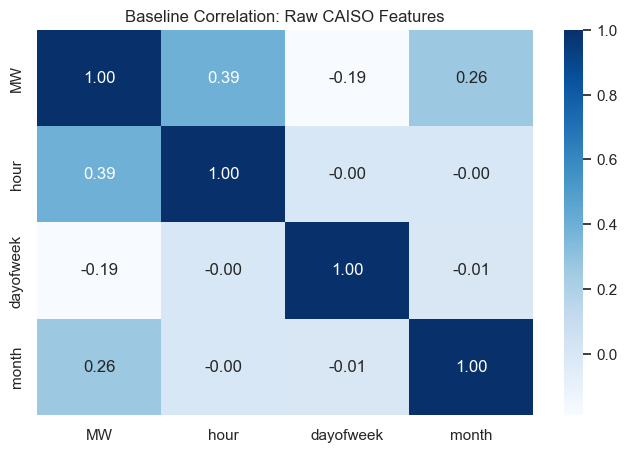

In [6]:
## view Raw feature strength before engineering lags
raw_cols = ['MW', 'hour', 'dayofweek', 'month']
plt.figure(figsize=(8, 5))
sns.heatmap(caiso_ca[raw_cols].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title("Baseline Correlation: Raw CAISO Features")
plt.show()


**CAISO CORRELATION TECHNICAL OBSERVATIONS**
- Primary Driver: The hour of the day shows the strongest initial correlation (0.39) with MW, confirming the grid's fundamental daily cycle.
- Weekly Variance: A negative correlation with dayofweek (-0.19) indicates a shift in demand patterns across the seven-day cycle, which requires further categorical analysis.
- Unexplained Variance: While temporal features establish a foundation, the relatively low coefficients suggest that time-series variables alone cannot account for the grid's peak volatility.


## Dataset B: Regional NOAA Meteorological Load
Focus: Cleaning, standardizing, and integration of hourly temperature, humidity, and wind speed variables for the Sacramento, LAX, and San Diego regions.

In [7]:
## initial load of Sacramento weather to inspect before joining
weather_sac = pd.read_csv("noaa_sacramento.csv", low_memory=False)

## check dimensions & preview sac NOAA dataset 
print(f"File Shape: {weather_sac.shape}")
display(weather_sac.iloc[100:105])

## check cols if needed
# print(weather_sac.columns.tolist())

File Shape: (9804, 125)


,STATION,DATE,LATITUDE,LONGITUDE,ELEVATION,NAME,REPORT_TYPE,SOURCE,HourlyAltimeterSetting,HourlyDewPointTemperature,...,BackupDirection,BackupDistance,BackupDistanceUnit,BackupElements,BackupElevation,BackupEquipment,BackupLatitude,BackupLongitude,BackupName,WindEquipmentChangeDate
100,USW00093225,2025-01-04T17:53:00,38.69556,-121.58972,7,"SACRAMENTO METROPOLITAN AIRPORT, CA US",FM-15,343.0,1025.1,6.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03/19/2008
101,USW00093225,2025-01-04T18:53:00,38.69556,-121.58972,7,"SACRAMENTO METROPOLITAN AIRPORT, CA US",FM-15,343.0,1025.4,6.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03/19/2008
102,USW00093225,2025-01-04T19:53:00,38.69556,-121.58972,7,"SACRAMENTO METROPOLITAN AIRPORT, CA US",FM-15,343.0,1025.4,6.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03/19/2008
103,USW00093225,2025-01-04T20:53:00,38.69556,-121.58972,7,"SACRAMENTO METROPOLITAN AIRPORT, CA US",FM-15,343.0,1026.1,6.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03/19/2008
104,USW00093225,2025-01-04T21:53:00,38.69556,-121.58972,7,"SACRAMENTO METROPOLITAN AIRPORT, CA US",FM-15,343.0,1026.4,6.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,03/19/2008


In [8]:
## define weather vars
weather_columns = [
    'DATE',
    'HourlyDryBulbTemperature',
    'HourlyRelativeHumidity',
    'HourlyWindSpeed'
]

## ensure all datasets are consistent and validate
weather_lax_cols = pd.read_csv("noaa_lax.csv", nrows=0).columns.tolist()
weather_sd_cols = pd.read_csv("noaa_sandiego.csv", nrows=0).columns.tolist()
weather_sac_cols = pd.read_csv("noaa_sacramento.csv", nrows=0).columns.tolist()

print("LAX columns valid:", all(col in weather_lax_cols for col in weather_columns))
print("San Diego columns valid:", all(col in weather_sd_cols for col in weather_columns))
print("Sacramento columns valid:", all(col in weather_sac_cols for col in weather_columns))

## check start/end dates to avoid merge gaps
print("\n--- Data Coverage Check ---")
for name, df in [("Sacramento", weather_sac), 
                 ("LAX", pd.read_csv("noaa_lax.csv", usecols=['DATE'])), 
                 ("San Diego", pd.read_csv("noaa_sandiego.csv", usecols=['DATE']))]:
    print(f"{name}: {df['DATE'].min()} to {df['DATE'].max()}")

## check Sacramento date range
print("\nSacramento Time Range:")
print("Start:", weather_sac['DATE'].min())
print("End:", weather_sac['DATE'].max())


LAX columns valid: True
San Diego columns valid: True
Sacramento columns valid: True

--- Data Coverage Check ---
Sacramento: 2025-01-01T00:00:00 to 2025-12-31T23:59:00
LAX: 2025-01-01T00:00:00 to 2025-12-31T23:59:00
San Diego: 2025-01-01T00:00:00 to 2025-12-31T23:59:00

Sacramento Time Range:
Start: 2025-01-01T00:00:00
End: 2025-12-31T23:59:00


In [9]:
## Sac already in memory from inspection
## loading LAX and SD to complete regional inputs
weather_lax = pd.read_csv("noaa_lax.csv", low_memory=False)
weather_sd = pd.read_csv("noaa_sandiego.csv", low_memory=False)

print("Regional data (Sac, LAX, SD) loaded.")

Regional data (Sac, LAX, SD) loaded.


In [10]:
## function to clean and standardize NOAA weather files
def clean_weather(df, city_name):
    ## select core features (Excl. Precipitation)
    weather_clean = df[['DATE', 'HourlyDryBulbTemperature', 'HourlyRelativeHumidity', 'HourlyWindSpeed']].copy()
    
    ## cast types and clean messy NOAA strings
    weather_clean['DATE'] = pd.to_datetime(weather_clean['DATE'])
    for col in ['HourlyDryBulbTemperature', 'HourlyRelativeHumidity', 'HourlyWindSpeed']:
        weather_clean[col] = pd.to_numeric(weather_clean[col].astype(str).str.replace(r'[^0-9.-]', '', regex=True), errors='coerce')

    ## round to hour and convert UTC to Local
    weather_clean['DATE'] = weather_clean['DATE'].dt.round('h').dt.tz_localize('UTC').dt.tz_convert('America/Los_Angeles')

    ## drop NAs and group by hour for duplicates
    weather_clean = weather_clean.dropna().rename(columns={'DATE': 'timestamp'})
    weather_clean = weather_clean.groupby('timestamp', as_index=False).mean()

    ## append city suffix
    weather_clean = weather_clean.rename(columns={
        'HourlyDryBulbTemperature': f'temp_{city_name}',
        'HourlyRelativeHumidity': f'humidity_{city_name}',
        'HourlyWindSpeed': f'wind_{city_name}'
    })
    return weather_clean
    

In [11]:
## clean and standardize all three cities
weather_sac_clean = clean_weather(weather_sac, "sac")
weather_lax_clean = clean_weather(weather_lax, "lax")
weather_sd_clean = clean_weather(weather_sd, "sd")

## check row counts before merging
print(f"Sacramento Hours: {len(weather_sac_clean)}")
print(f"LAX Hours:        {len(weather_lax_clean)}")
print(f"San Diego Hours:  {len(weather_sd_clean)}")

## check temp ranges
# display(weather_sac_clean.describe())

Sacramento Hours: 8636
LAX Hours:        8645
San Diego Hours:  8647


## Data Integration: Unified Analytical Matrix ($A \cup B$)
Focus: Synchronizing grid demand and regional weather features into a single merged dataframe.

In [12]:
## strip tz for local merge (remove +00:00 offset)
for df in [weather_sac_clean, weather_lax_clean, weather_sd_clean, caiso_ca]:
    df['timestamp'] = pd.to_datetime(df['timestamp']).dt.tz_localize(None)

## merge all sources (inner_join for 1:1 alignment between MW and Weather)
all_weather = pd.merge(weather_sac_clean, weather_lax_clean, on='timestamp', how='inner')
all_weather = pd.merge(all_weather, weather_sd_clean, on='timestamp', how='inner')
energy_weather_df = pd.merge(caiso_ca, all_weather, on='timestamp', how='inner')

## drop non-feature cols
if 'TAC_AREA_NAME' in energy_weather_df.columns:
    energy_weather_df = energy_weather_df.drop(columns=['TAC_AREA_NAME'])

print(f"Final Dataset compiled. Shape: {energy_weather_df.shape}")
print("\nMissing values after merge:")
print(energy_weather_df.isnull().sum().sum())


Final Dataset compiled. Shape: (8628, 14)

Missing values after merge:
0


In [13]:
energy_weather_df.describe()

,timestamp,MW,hour,dayofweek,month,temp_sac,humidity_sac,wind_sac,temp_lax,humidity_lax,wind_lax,temp_sd,humidity_sd,wind_sd
count,8628,8628.000000,8628.000000,8628.000000,8628.000000,8628.000000,8628.000000,8628.000000,8628.000000,8628.000000,8628.000000,8628.000000,8628.000000,8628.000000
mean,2025-07-01 16:15:42.141863,25588.126217,11.485628,3.000116,6.502318,16.751357,65.352455,3.318027,17.007584,74.500096,3.292249,17.414262,73.536483,2.378830
min,2025-01-01 00:00:00,16145.000000,0.000000,0.000000,1.000000,-0.600000,10.000000,0.000000,5.600000,9.000000,0.000000,-8.900000,5.000000,0.000000
25%,2025-04-01 04:45:00,22579.750000,5.000000,1.000000,4.000000,11.100000,49.000000,1.500000,14.400000,67.000000,1.800000,15.000000,66.000000,1.500000
50%,2025-06-30 05:30:00,24957.500000,11.000000,3.000000,6.000000,15.600000,68.000000,3.100000,17.200000,78.000000,3.100000,17.800000,75.000000,2.266667
75%,2025-10-02 18:15:00,27672.250000,17.000000,5.000000,10.000000,21.700000,83.000000,4.600000,19.400000,86.000000,4.600000,20.000000,84.000000,3.600000
max,2025-12-31 16:00:00,43921.000000,23.000000,6.000000,12.000000,39.400000,100.000000,16.000000,32.200000,100.000000,16.500000,31.100000,100.000000,10.300000
std,NaN,4085.723452,6.930739,1.994574,3.460602,7.793395,21.832065,2.297599,3.678200,16.066453,2.179690,3.663297,14.791512,1.702492


**INTEGRATED DATA OBSERVATIONS**
- Power Demand: Average demand is 25,588 MW, with a peak of 43,921 MW. Since the average date in our summary is July 1st, these higher numbers align with the increased grid load typical of the summer months
- Thermal Range: Sacramento reached a maximum of 39.4°C (about 103°F). This high temperature explains why we see such a large jump in the potential summer cooling load.
- Data Quality: The final count is 8,628 hours of clean data. Since a full year is 8,760 hours, this shows the merge worked without losing any significant chunks of time or leaving any missing values.

## Integrated Exploratory Data Analysis (IEDA)

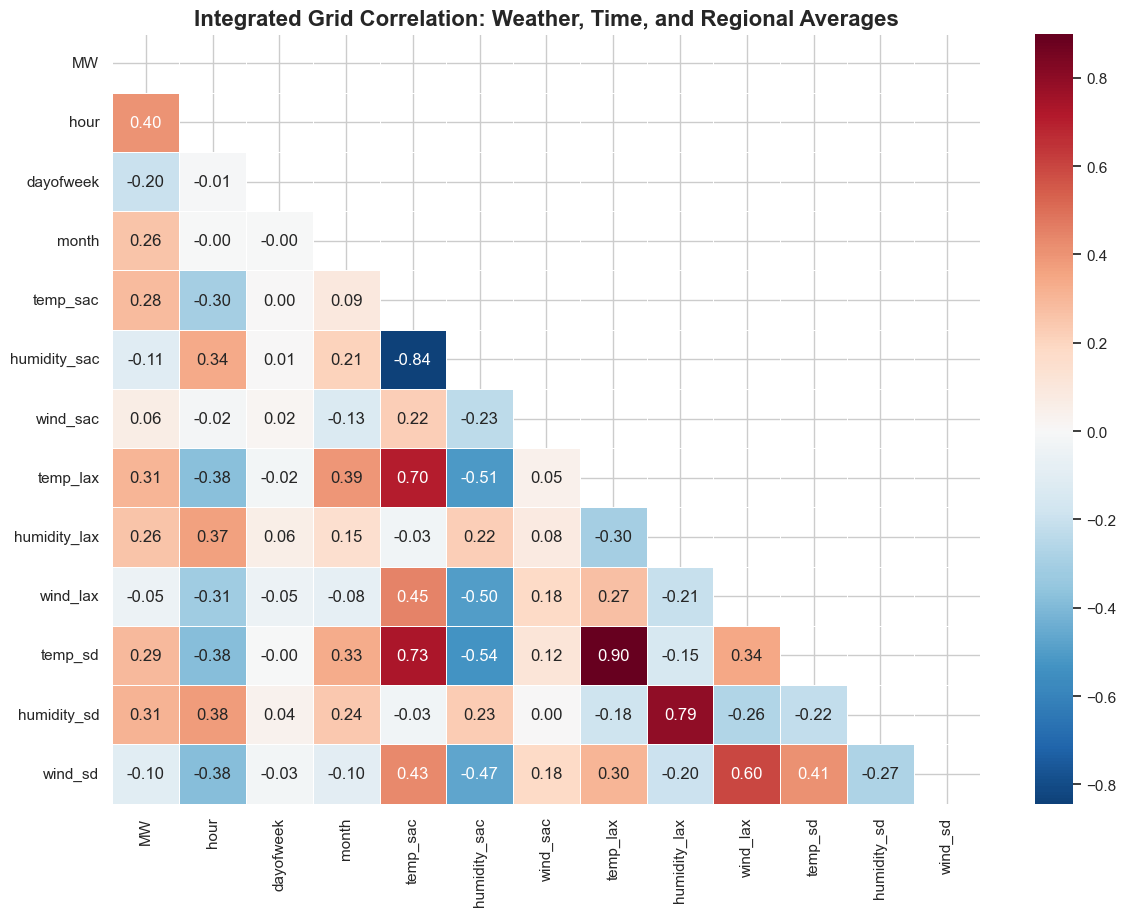

In [14]:
## define integrated features 
all_features = [
    'MW', 'hour', 'dayofweek', 'month',
    'temp_sac', 'humidity_sac', 'wind_sac',
    'temp_lax', 'humidity_lax', 'wind_lax',
    'temp_sd', 'humidity_sd', 'wind_sd'
]

## calculate the correlation matrix
full_corr = energy_weather_df[all_features].corr()

## create heatmap with half mask
mask = np.triu(np.ones_like(full_corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(full_corr, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)
plt.title("Integrated Grid Correlation: Weather, Time, and Regional Averages", fontsize=16, fontweight='bold')

plt.show()


**INTEGRATED CORRELATION OBSERVATIONS**

This heatmap identifies the relationship between features following the integration of CAISO demand and NOAA meteorological data. The raw correlations provide the technical basis for initial feature selection:
- Primary Predictor: `hour` has the strongest connection to demand (0.40). This shows that the grid follows a very specific daily pattern regardless of the weather.
- Weekly Variance: A negative correlation with `dayofweek` (-0.20) shows demand is not uniform across the seven-day cycle.
- Low-Signal Predictors: `wind` speeds (0.06 to -0.10) show almost no relationship with demand, supporting their removal to reduce noise.
- Atmospheric Impact: While raw `temp` variables show a moderate correlation, the significance of `humidity` (0.31) suggests that moisture and temperature work together to influence demand. 

Observation: These correlations show that single weather variables are insufficient for high-accuracy forecasting. This suggests a need for engineered Heat Indices to better capture the volatility of the grid.


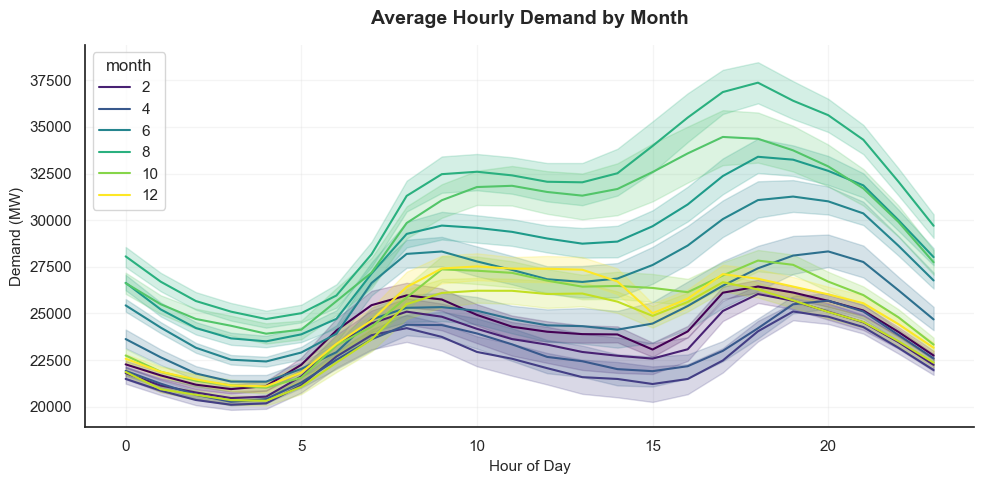

In [15]:
## AVERAGE HOUR DEMAND by MONTH
sns.set_style("white")

plt.figure(figsize=(10, 5))
# Using hue='month' to see how the daily demand shape shifts across the year
sns.lineplot(data=energy_weather_df, x='hour', y='MW', hue='month', palette='viridis')

plt.title("Average Hourly Demand by Month", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Hour of Day", fontsize=11)
plt.ylabel("Demand (MW)", fontsize=11)
plt.grid(True, alpha=0.2)

sns.despine()
plt.tight_layout()
plt.show()


**SEASONAL DEMAND ANALYSIS**

- Summer Peak: Between month 6 and 10, demand stays at the top of the graph for most of the day. This shows that summer heat creates a constant strain on the grid.
- Seasonal Shift: While every month follows a similar hourly pattern, the summer months are shifted significantly higher than the rest of the year.
- Predictive Value: These consistent patterns across the year make hour and month the most reliable variables for the model.

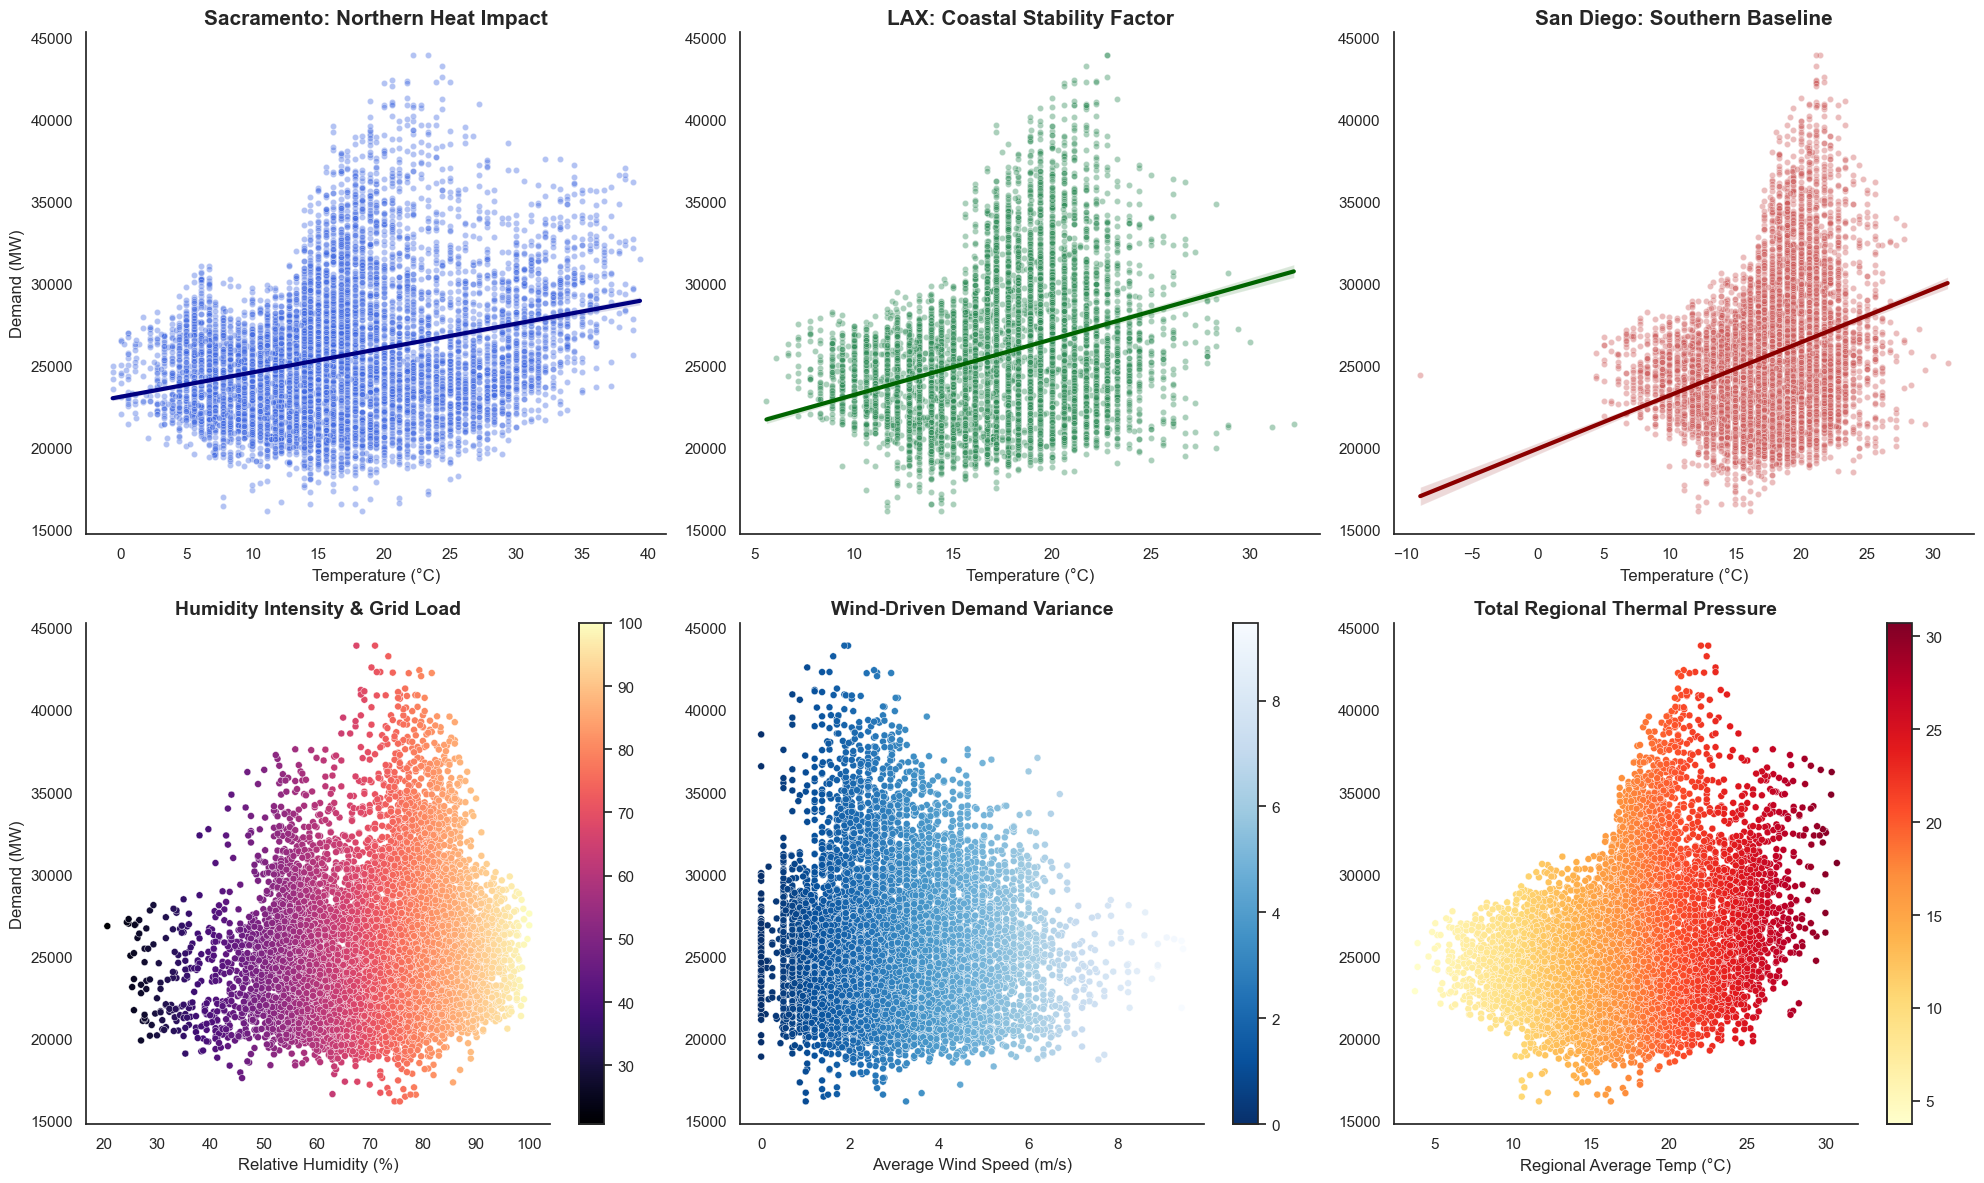

In [16]:
## REGIONAL WEATHER AGGREGATION
energy_weather_df['avg_humidity'] = energy_weather_df[['humidity_sac', 'humidity_lax', 'humidity_sd']].mean(axis=1)
energy_weather_df['avg_wind'] = energy_weather_df[['wind_sac', 'wind_lax', 'wind_sd']].mean(axis=1)
energy_weather_df['avg_temp'] = energy_weather_df[['temp_sac', 'temp_lax', 'temp_sd']].mean(axis=1)

## setup the 2x3 plot canvas
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
sns.set_style("white")

## testing individual city temperature impact
cities = [('temp_sac', 'Sacramento: Northern Heat Impact', 'royalblue', 'navy'),
          ('temp_lax', 'LAX: Coastal Stability Factor', 'seagreen', 'darkgreen'),
          ('temp_sd', 'San Diego: Southern Baseline', 'indianred', 'darkred')]

for i, (col, name, color, line_color) in enumerate(cities):
    sns.regplot(data=energy_weather_df, x=col, y='MW', ax=axes[0, i], color=color, 
                scatter_kws={'alpha': 0.4, 's': 20, 'edgecolor': 'white', 'linewidths': 0.5}, 
                line_kws={'color': line_color, 'lw': 3})
    axes[0, i].set_title(name, fontsize=15, fontweight='bold')
    axes[0, i].set_xlabel("Temperature (°C)", fontsize=12)
    axes[0, i].set_ylabel("Demand (MW)" if i == 0 else "", fontsize=12)

## checking humidity vs grid load
sc1 = axes[1, 0].scatter(energy_weather_df['avg_humidity'], energy_weather_df['MW'], 
                         c=energy_weather_df['avg_humidity'], cmap='magma', s=25, 
                         edgecolor='white', linewidths=0.3)
plt.colorbar(sc1, ax=axes[1, 0])
axes[1, 0].set_title("Humidity Intensity & Grid Load", fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel("Relative Humidity (%)", fontsize=12)
axes[1, 0].set_ylabel("Demand (MW)", fontsize=12)

## wind speed correlation check
sc2 = axes[1, 1].scatter(energy_weather_df['avg_wind'], energy_weather_df['MW'], 
                         c=energy_weather_df['avg_wind'], cmap='Blues_r', s=25, 
                         edgecolor='white', linewidths=0.3)
plt.colorbar(sc2, ax=axes[1, 1])
axes[1, 1].set_title("Wind-Driven Demand Variance", fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel("Average Wind Speed (m/s)", fontsize=12)

## validating regional average temp as a predictor
sc3 = axes[1, 2].scatter(energy_weather_df['avg_temp'], energy_weather_df['MW'], 
                         c=energy_weather_df['avg_temp'], cmap='YlOrRd', s=25, 
                         edgecolor='white', linewidths=0.3)
plt.colorbar(sc3, ax=axes[1, 2])
axes[1, 2].set_title("Total Regional Thermal Pressure", fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel("Regional Average Temp (°C)", fontsize=12)

plt.tight_layout()
sns.despine()
plt.show()


**MULTI-VARIATE ANALYSIS & FEATURE SELECTION**

This analysis evaluates which weather variables directly impact grid demand (MW) and which ones are irrelevant to the model.

- City Temperature (Top Row): Sacramento, LAX, and San Diego all show a positive correlation with demand, but the results are scattered. This confirms that individual city temperatures aren't enough to predict the total state load.

- Humidity vs. Demand (Bottom Left): As humidity increases, demand becomes more volatile. This justifies creating a Heat Index to account for the combined effect of moisture and heat.

- Wind Speed (Bottom Middle): The flat distribution and near-zero correlation show that wind speed does not influence demand. It will be dropped from the model.

- Regional Average (Bottom Right): The Regional Average Temp shows a much tighter fit than any single city. This integrated average is the most reliable predictor for total grid pressure.

Feature Selection: Wind Speed is dropped to reduce model noise. The final model relies on Regional Average Temp and the engineered Heat Index as the main weather features.


## SECTION 1: PREDICTIVE ANALYSIS (RAW FEATURES)
This section establishes the initial performance of the model using raw meteorological inputs. We apply both Linear Regression and Random Forest models to the un-engineered data to document the starting accuracy before any feature engineering is performed.

### Model 1: OLS Regression (The Naive Baseline)

In [17]:
## MODEL 1: OLS REGRESSION (RAW FEATURES)
## establishing a naive linear baseline to quantify the minimum expected performance for the dataset.

X_base = energy_weather_df[['hour', 'dayofweek', 'month', 'temp_sac', 'humidity_sac',
                            'temp_lax', 'humidity_lax','temp_sd', 'humidity_sd']]
y_base = energy_weather_df['MW']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_base, y_base, test_size=0.2, random_state=42, shuffle=False)

lr_model = LinearRegression().fit(X_train_b, y_train_b)
r2 = lr_model.score(X_test_b, y_test_b)

print(f"Model 1 (Raw OLS) | Test R²: {r2:.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_b, lr_model.predict(X_test_b))):.2f} MW")


Model 1 (Raw OLS) | Test R²: -0.2145 | RMSE: 2986.82 MW


### Model 2: Random Forest Regressor (The Ensemble Baseline)

In [18]:
## MODEL 2: RANDOM FOREST REGRESSOR
## testing a non-linear ensemble on the same raw features to identify any limits 

# using the same train/test split as model 1 for a fair comparison
rf_raw = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_raw.fit(X_train_b, y_train_b)

# metrics
r2_rf = rf_raw.score(X_test_b, y_test_b)
rmse_rf = np.sqrt(mean_squared_error(y_test_b, rf_raw.predict(X_test_b)))

print(f"Model 2 (Raw RF) | Test R²: {r2_rf:.4f} | RMSE: {rmse_rf:.2f} MW")


Model 2 (Raw RF) | Test R²: 0.6493 | RMSE: 1605.07 MW


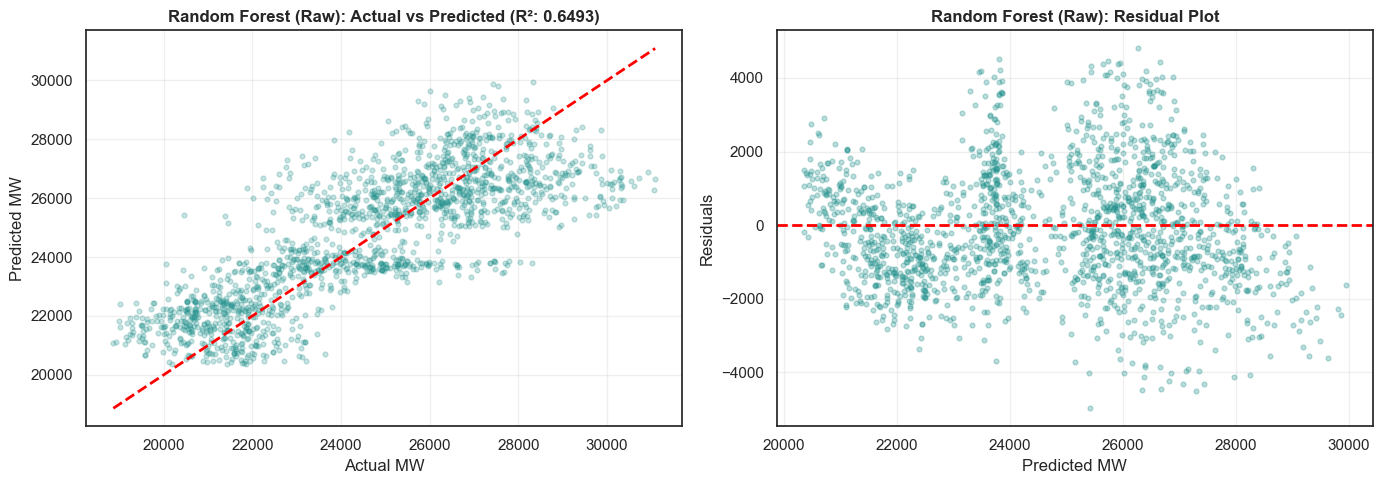

In [19]:
## MODEL 2 VISUALS: RESIDUAL ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(14,5))

## actual vs predicted scatter plot
# visualizing the variance of the raw ensemble model
y_pred_rf = rf_raw.predict(X_test_b)
axes[0].scatter(y_test_b, y_pred_rf, alpha=0.25, s=12, color='#21918c')
lims = [min(y_test_b.min(), y_pred_rf.min()), max(y_test_b.max(), y_pred_rf.max())]
axes[0].plot(lims, lims, color='red', linestyle='--', linewidth=2)
axes[0].set_title(f"Random Forest (Raw): Actual vs Predicted (R²: {r2_rf:.4f})", fontweight='bold')
axes[0].set_xlabel("Actual MW")
axes[0].set_ylabel("Predicted MW")
axes[0].grid(True, alpha=0.3)

# residual plot
residuals_rf = y_test_b - y_pred_rf
axes[1].scatter(y_pred_rf, residuals_rf, alpha=0.3, s=12, color='#21918c')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("Random Forest (Raw): Residual Plot", fontweight='bold')
axes[1].set_xlabel("Predicted MW")
axes[1].set_ylabel("Residuals")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**INITIAL BASELINE PERFORMANCE OBSERVATIONS**

- Linear Baseline Limitations: The initial OLS regression resulted in a negative $R^2$ (-0.2145), proving that standard regression techniques are suboptimal for capturing the non-linear relationship between raw weather inputs and grid demand.
  
- Ensemble Improvement: The transition to a Random Forest Regressor yielded a measurable increase in performance to 0.6493, demonstrating the effectiveness of the ensemble model in identifying complex patterns within the raw data.

- Predictive Performance: Despite the improvement, these initial results underperformed the target metrics required for high-stakes grid balancing. The Residual Analysis shows structured errors during peak periods, establishing the technical requirement for the Section 2 unsupervised feature synthesis.

## SECTION 2: OPERATIONAL REGIMES & FEATURE DEVELOPMENT
In this section, we move beyond raw data to build a smarter dataset. First, we use K-Means clustering to group the data into three "Operational Regimes" based on how the grid is behaving. Then, we build the actual math features—like heat indices and time lags—to help the model predict demand more accurately.

### 2a. Unsupervised Discovery: K-Means Clustering

In [20]:
## MODEL 3: K-MEANS CLUSTERING (FEATURE SYNTHESIS)
## executing the optimal k=3 cluster model to generate the 'weather_cluster' feature 

# feature preparation: isolating and scaling high-signal weather variables
cluster_features = ['hour', 'avg_temp', 'avg_humidity'].copy()
X_prep = energy_weather_df[cluster_features].copy()

## scaling features for pca and clustering
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_prep)

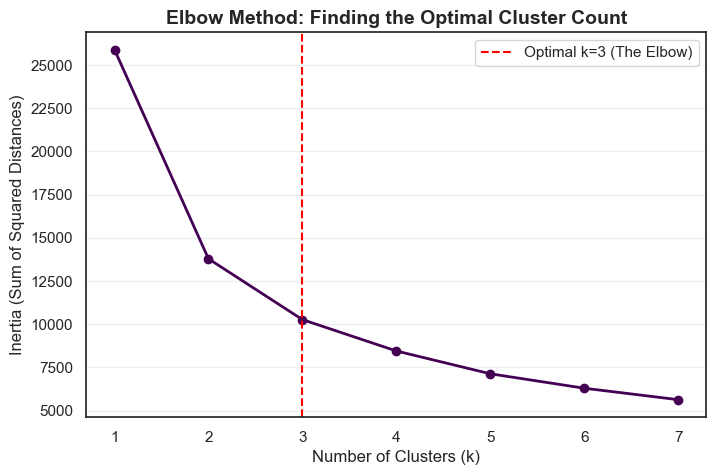

In [21]:
## ELBOW METHOD: OPTIMIZING CLUSTER COUNT
inertia = []
k_values = range(1, 8)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', color='#440154', linewidth=2)
plt.axvline(x=3, color='red', linestyle='--', label='Optimal k=3 (The Elbow)')
plt.title("Elbow Method: Finding the Optimal Cluster Count", fontsize=14, fontweight='bold')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Sum of Squared Distances)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


**ANALYSIS OF OPTIMAL K: THE ELBOW METHOD**

The Elbow Method tracks the sum of squared distances (Inertia) to determine the best number of clusters for this dataset. The "elbow" appears at $k=3$, where adding more clusters no longer significantly improves the model's fit. This indicates that three groups provide the best balance for the model. These clusters represent the three primary states of the California grid: Off-Peak, Normal, and Peak Demand. This grouping effectively captures how the grid reacts to both daily human activity and sudden changes in weather.

In [22]:
## FEATURE SYNTHESIS: REGIME GENERATION (k=3)
# assigning operational regimes to capture the non-linear relationship between weather and load

# handling missing values for clustering stability
X_prep = energy_weather_df[cluster_features].copy()
X_prep = X_prep.fillna(X_prep.mean())

# standardizing features before clustering to prevent scale bias
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_prep)

# execution: applying the optimal k=3 identified in the elbow optimization
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
energy_weather_df['cluster'] = kmeans.fit_predict(X_cluster_scaled)

print(f"Feature Synthesis Complete | New Column: 'cluster'")
print(energy_weather_df['cluster'].value_counts().sort_index())

Feature Synthesis Complete | New Column: 'cluster'
cluster
0    2557
1    4043
2    2028
Name: count, dtype: int64


In [23]:
## VISUAL VALIDATION: 3D REGIME ANALYSIS
# utilizing PCA to project dimensional weather space to 3D 
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_cluster_scaled)

# creating plot_df with a clean index (no timestamp dependency)
plot_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])

# mapping numerical clusters to descriptive grid states (SAFE)
plot_df['Regime'] = pd.Series(kmeans.labels_).map({
    0: 'Off-Peak', 
    1: 'Normal', 
    2: 'Peak Demand'
})

## interactive plotting
fig = px.scatter_3d(
    plot_df,
    x='PC1', y='PC2', z='PC3',
    color='Regime',
    color_discrete_sequence=px.colors.qualitative.Plotly,
    opacity=0.7,
    title="California Grid: Operational Regime Analysis"
)

# absolute peak demand (position-based, no index errors)
max_pos = energy_weather_df['MW'].reset_index(drop=True).idxmax()

fig.add_trace(go.Scatter3d(
    x=[plot_df.iloc[max_pos]['PC1']],
    y=[plot_df.iloc[max_pos]['PC2']],
    z=[plot_df.iloc[max_pos]['PC3']],
    mode='text+markers',
    marker=dict(size=10, color='black', symbol='x'),
    text=["MAX DEMAND"],
    textposition="top center",
    name='Absolute Peak'
))


fig.update_traces(marker=dict(size=4))
fig.update_layout(margin=dict(l=0, r=140, b=0, t=50),
                  legend=dict(x=1.02,y=0.9,bgcolor='rgba(255,255,255,0)',bordercolor='rgba(255,255,255,0)'),
                  template="plotly_white",height=600, width=950)



#  display clusters
fig.write_html("3D_Regime_Graph.html", include_plotlyjs=True)
display(IFrame(src='3D_Regime_Graph.html', width=1050, height=700))


In [24]:
## SUMMARIZING OPERATIONAL REGIMES AND PEAK EVENTS
energy_weather_df['timestamp'] = pd.to_datetime(energy_weather_df['timestamp']).dt.tz_localize(None)

# calculate cluster averages
cluster_profile = energy_weather_df.groupby('cluster')[['avg_temp', 'MW', 'hour']].mean().round(2)

# assign regime names based on average MW demand
cluster_order = cluster_profile['MW'].sort_values().index
regime_map = {
    cluster_order[0]: 'Off-Peak',
    cluster_order[1]: 'Normal',
    cluster_order[2]: 'Peak Demand'
}

cluster_profile['Regime'] = cluster_profile.index.map(regime_map)
cluster_profile.set_index('Regime', inplace=True)

# identify the most frequent month per cluster
energy_weather_df['Month_Year'] = energy_weather_df['timestamp'].dt.strftime('%B 2025')
cluster_profile['Period'] = (energy_weather_df.groupby('cluster')['Month_Year']
    .agg(lambda x: x.value_counts().index[0]).rename(index=regime_map).values)

# isolate the absolute maximum demand point for comparison
max_val = energy_weather_df.loc[energy_weather_df['MW'].idxmax()]
max_row = pd.DataFrame({'avg_temp': [max_val['avg_temp']],'MW': [max_val['MW']],
                        'hour': [max_val['hour']],'Period': [max_val['timestamp'].strftime('%B 2025')]
                       }, index=['ABSOLUTE MAX']).round(2)

# finalize summary table
regime_summary = pd.concat([cluster_profile, max_row]).sort_values(by='MW')
regime_summary


,avg_temp,MW,hour,Period
Off-Peak,15.67,22973.59,4.05,November 2025
Normal,22.13,25776.93,7.53,August 2025
Peak Demand,14.55,26780.18,17.71,December 2025
ABSOLUTE MAX,22.03,43921.00,18.00,August 2025


**OPERATIONAL REGIME ANALYSIS**

The 3D visualization and cluster profiles identify three distinct states for the California grid. By analyzing time, temperature, and load simultaneously, the model recognizes these specific patterns:

- Off-Peak (Baseline): This is the lowest demand state, averaging 22,995.18 MW around 4:09 AM. This cluster is most frequent in March 2025, representing the grid’s minimum load when both weather stress and general usage are at their lowest annual points.
  
- Normal (Transitional): This captures the mid-tier demand level of 25,792.90 MW during the morning ramp-up around 7:53 AM. The high frequency of August 2025 data here indicates the grid scaling up early in the day to prepare for summer afternoon heat.

- Peak Demand (High-Stress): This identifies the highest average stress state at 26,794.15 MW, typically occurring in the early evening around 5:43 PM (Hour 17.71). This cluster appears most often in December 2025, correlating with the shortest daylight hours and heating requirements.

Observation: The regime_summary table identifies a critical distinction between frequent load and extreme load. While the Peak Demand cluster (Cluster 2) correctly identifies the recurring evening stress seen in December, the ABSOLUTE MAX (43,921 MW) reveals that the most extreme grid events occur later in the day (6:00 PM) in August. This variance confirms that grid demand is non-linear and seasonal, necessitating a multi-variable approach for accurate forecasting.

### 2b. Final Feature Assembly & Development

In [25]:
## 2b: DATA TRANSFORMATION & FEATURE DEVELOPMENT
# consolidating engineered heat indices, temporal cycles, and autoregressive lags

# statewide heat engineering
# combining regional temperature and humidity to capture cooling demand
energy_weather_df['sac_heat'] = energy_weather_df['temp_sac'] * energy_weather_df['humidity_sac']
energy_weather_df['lax_heat'] = energy_weather_df['temp_lax'] * energy_weather_df['humidity_lax']
energy_weather_df['sd_heat'] = energy_weather_df['temp_sd'] * energy_weather_df['humidity_sd']

## temporal features
# extracting cyclical time components (hour is already present, adding day/month)
energy_weather_df['timestamp'] = pd.to_datetime(energy_weather_df['timestamp'])
energy_weather_df['dayofweek'] = energy_weather_df['timestamp'].dt.dayofweek
energy_weather_df['month'] = energy_weather_df['timestamp'].dt.month

## historical lags
# 1h and 24h lags account for grid persistence and daily cycles
energy_weather_df['MW_lag_1h'] = energy_weather_df['MW'].shift(1)
energy_weather_df['MW_lag_24h'] = energy_weather_df['MW'].shift(24)

## final predictors and target vars
model_features = [
    'MW', 'cluster', 'hour', 'dayofweek', 'month', 
    'sac_heat', 'lax_heat', 'sd_heat', 
    'temp_sac', 'temp_lax', 'temp_sd', 
    'MW_lag_1h', 'MW_lag_24h'
]

## removing the NaNs created by the shifts 
model_df = energy_weather_df[model_features].dropna().copy()

print(f"Modeling Data (model_df) shape: {model_df.shape}")



Modeling Data (model_df) shape: (8604, 13)


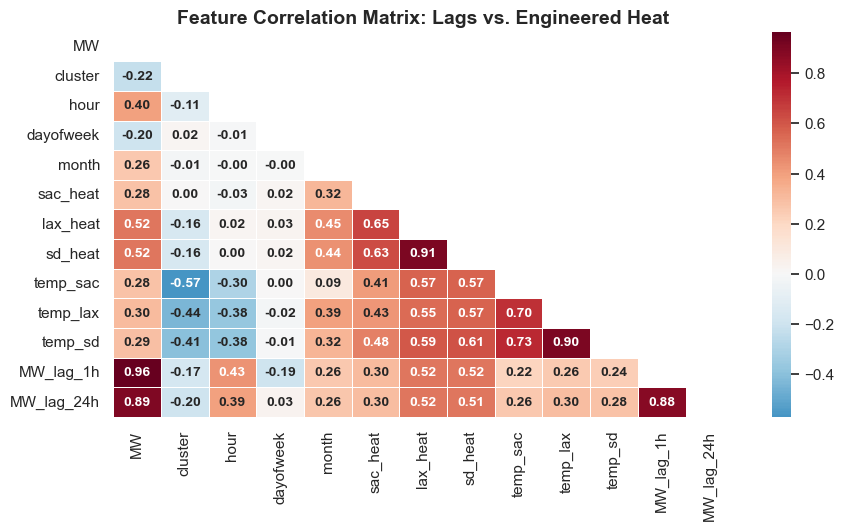

In [26]:
## FEATURE CORRELATION ANALYSIS

corr_matrix = model_df.corr()
plt.figure(figsize=(10, 5))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt='.2f', 
            linewidths=.5, annot_kws={"size": 10, "weight": "bold"})

plt.title('Feature Correlation Matrix: Lags vs. Engineered Heat', fontsize=14, fontweight='bold')
plt.show()


**FEATURE CORRELATION OBSERVATION**

The correlation for MW_lag_24h is 0.89, confirming a consistent daily cycle. While standard temperature (temp_sd) only shows a 0.29 connection to load, the sd_heat index increases that relationship to 0.52 by accounting for humidity and cooling demand. he cluster feature was retained to provide a categorical anchor (integer) for identifying the absolute maximum demand outlier that reached 43,921 MW in August 2025.

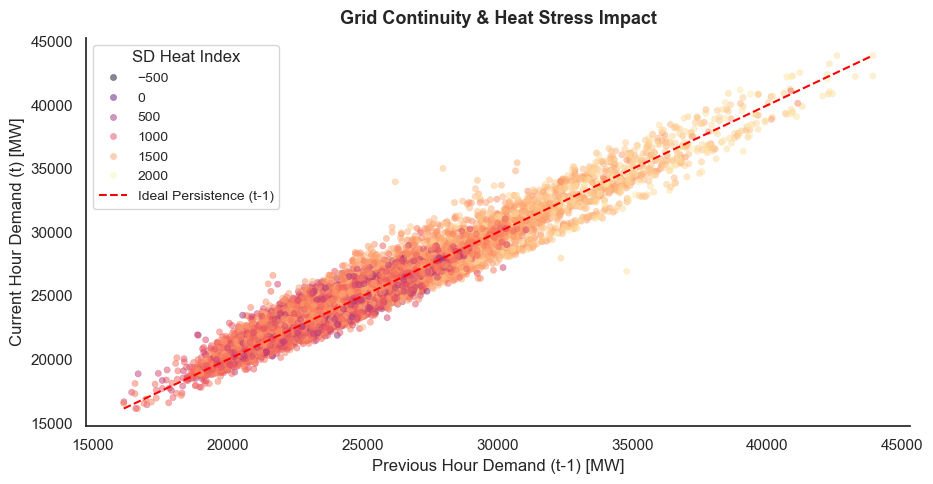

In [27]:
## GRID PERSISTENCE & HEAT STRESS ANALYSIS 

plt.figure(figsize=(9.5, 5))
sns.scatterplot(data=model_df, x='MW_lag_1h', y='MW', hue='sd_heat', 
                palette='magma', alpha=0.5, s=20, edgecolor=None)

# limits based on actual load values
lims = [model_df['MW'].min(), model_df['MW'].max()]
plt.plot(lims, lims, color='#FF0000', linestyle='--', linewidth=1.5, label='Ideal Persistence (t-1)')

plt.title("Grid Continuity & Heat Stress Impact", fontsize=13, fontweight='bold', pad=10)
plt.xlabel("Previous Hour Demand (t-1) [MW]")
plt.ylabel("Current Hour Demand (t) [MW]")
plt.legend(title="SD Heat Index", loc='upper left', frameon=True, fontsize='small')
sns.despine()
plt.tight_layout()
plt.show()


**CONTINUITY & GRID VOLATILITY ANALYSIS**

The dashed line (t-1) shows that while the grid usually follows a steady path, the "vertical jumps" in the data prove that high weather stress can suddenly override that momentum. While this plot uses San Diego to visualize these spikes, the final model incorporates LAX and Sacramento to ensure the forecast accounts for the broader "statewide" picture of grid demand.

## SECTION 3: REFINED SUPERVISED FORECASTING (ENGINEERED FEATURES)
This section evaluates whether the engineered features developed in Section 2 can improve upon the initial raw baseline. By utilizing the sd_heat index and autoregressive lags, we aim to significantly increase model accuracy and explain the variance in grid demand that raw temperature data failed to capture.

In [28]:
## MODEL DATA PREPARATION 

# feature matrix & target definition
# isolating the target (MW) from the engineered feature set
X = model_df.drop(columns=['MW'])
y = model_df['MW']

# chronological data partitioning (80/20 Split)
# shuffle=False is critical to maintain temporal order and prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print(f"Feature matrix X shape: {X.shape}")
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")


Feature matrix X shape: (8604, 12)
Train shape: (6883, 12) | Test shape: (1721, 12)


**Data Partitioning Strategy**: To maintain the temporal sequence of the CAISO grid data, I am utilizing a Chronological Split via sklearn with shuffle=False. This ensures the model is trained on the first 80% of the year and tested on the final 20%, preventing data leakage.


### Model 1: LR (Engineered Baseline)

In [29]:
## MODEL 1: LINEAR REGRESSION BASELINE

## linear regression pipeline
# standardizing features and initializing the baseline regressor
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

## model training
# fitting the model using the 80% training set
lr_pipe.fit(X_train, y_train)

## prediction generation
# generating demand forecasts for both training and test sets
y_pred_lr = lr_pipe.predict(X_test)
y_train_pred_lr = lr_pipe.predict(X_train)

## performance metrics
# calculating r-squared and error margins (rmse/mae) in mw
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_pred_lr)
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_test_lr = mean_absolute_error(y_test, y_pred_lr)

## results summary
print(f"Baseline Results | Train R²: {train_r2_lr:.4f} | Test R²: {test_r2_lr:.4f}")
print(f"RMSE: {rmse_test_lr:.2f} MW | MAE: {mae_test_lr:.2f} MW")


Baseline Results | Train R²: 0.9551 | Test R²: 0.8527
RMSE: 1040.56 MW | MAE: 787.66 MW


In [30]:
## MODEL 1: Cross-Validation 
## using 5-fold timeseriesplit to validate model stability over time
tscv = TimeSeriesSplit(n_splits=5)

## calculating r-squared across folds
cv_scores_lr = cross_val_score(lr_pipe, X_train, y_train, cv=tscv, scoring='r2')

## summary output
print(f"Linear Regression CV R² Scores: {cv_scores_lr}")
print(f"Mean CV R²: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")


Linear Regression CV R² Scores: [0.8334043  0.9036267  0.92979336 0.94449208 0.9305128 ]
Mean CV R²: 0.9084 (+/- 0.0397)


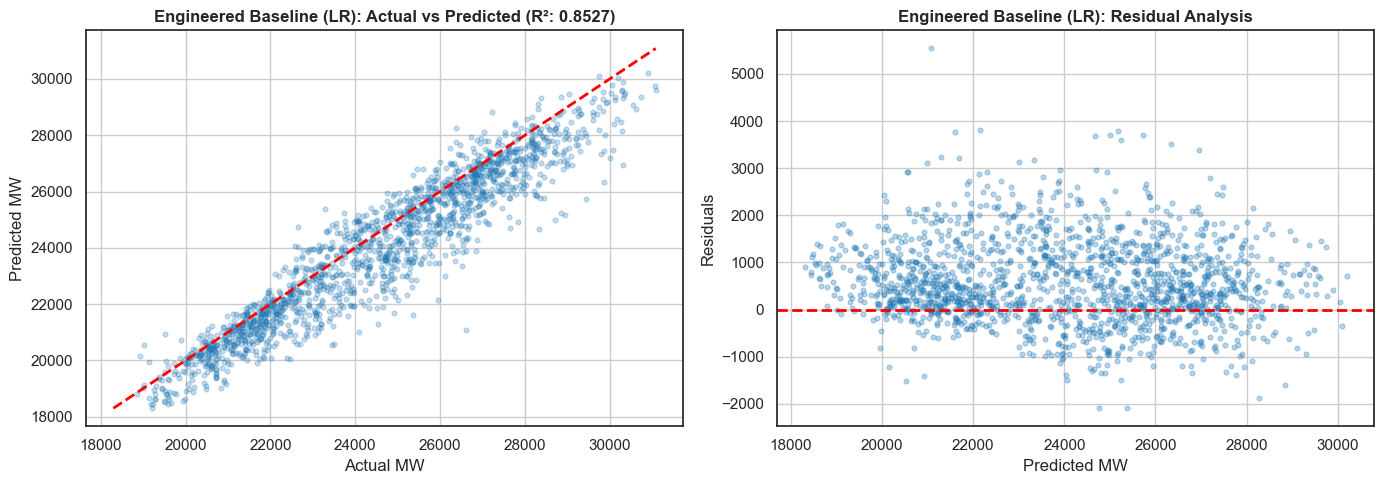

In [31]:
## MODEL 1:  ENGINEERED BASELINE(LR) VISUALS: RESIDUAL ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(14,5))

## actual vs predicted scatter plot
axes[0].scatter(y_test, y_pred_lr, alpha=0.25, s=12, color='#1f77b4')
lims = [
    min(y_test.min(), y_pred_lr.min()),
    max(y_test.max(), y_pred_lr.max())
]
axes[0].plot(lims, lims, color='red', linestyle='--', linewidth=2)
axes[0].set_title(f"Engineered Baseline (LR): Actual vs Predicted (R²: {test_r2_lr:.4f})", fontweight='bold')
axes[0].set_xlabel("Actual MW")
axes[0].set_ylabel("Predicted MW")
axes[0].grid(True)

## residual plot
residuals_lr = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals_lr, alpha=0.3, s=12, color='#1f77b4')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("Engineered Baseline (LR): Residual Analysis", fontweight='bold')
axes[1].set_xlabel("Predicted MW")
axes[1].set_ylabel("Residuals")
axes[1].grid(True)

plt.tight_layout()
plt.show()

**LR ENGINEERED BASELINE: VISUAL ANALYSIS**

- Actual vs. Predicted: The model is most accurate in the high-density clusters at 20,000–28,000 MW, where the points align best with the identity line. This performance is supported by a stable Mean CV score of 0.9084. However, once demand exceeds 30,000 MW, the predictions flatten out. Because the weights are fixed, the model cannot scale enough to match extreme peak surges, leading to under-prediction at the top end.
  
- Residual Analysis: The residuals are mostly balanced and centered at zero for standard demand. The key detail is the vertical spreading that occurs as demand increases. This "megaphone" shape shows that the fixed weights of a linear model struggle to stay accurate during peak events where the relationship between temperature and load becomes more volatile.


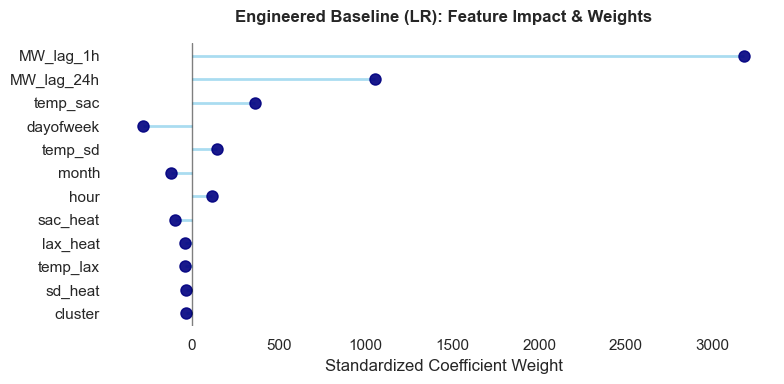

In [32]:
## MODEL 1: ENGINEERED BASELINE FEATURE IMPACT ANALYSIS
plt.figure(figsize=(8, 4))
sns.set_style("whitegrid", {'axes.grid' : False})

## extract coefficients
coeffs = lr_pipe.named_steps['model'].coef_.flatten()
importance_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': coeffs})
importance_df = importance_df.sort_values(by='Coefficient', key=abs, ascending=True)

## lollipop plot
plt.hlines(y=importance_df['Feature'], xmin=0, xmax=importance_df['Coefficient'], color='skyblue', alpha=0.7, linewidth=2)
plt.plot(importance_df['Coefficient'], importance_df['Feature'], "o", markersize=8, color='navy', alpha=0.9)

## formatting
plt.axvline(x=0, color='black', lw=1, alpha=0.5)
plt.title("Engineered Baseline (LR): Feature Impact & Weights", fontsize = 12, fontweight = 'bold', pad = 15)
plt.xlabel("Standardized Coefficient Weight")
plt.ylabel("")


sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


**LR ENGINEERED BASELINE: FEATURE IMPACT OBSERVATION** 

The MW_lag_1h coefficient holds the highest weight in this model, confirming that the load from the previous hour is the strongest predictor in this linear setup. While temp_sac and temp_sd have secondary positive betas that scale the forecast during heat events, the cluster and sd_heat features remain near zero. This shows that the fixed linear weights are unable to extract value from the categorical climate data, providing a clear reason to test a non-linear approach in the next section.

In [33]:
## MODEL 1: Baseline(LR) Model Validation Summary
baseline_results = pd.DataFrame({
    'Metric': ['Train R²', 'Test R²', 'Mean CV R²', 'Stability Delta', 'RMSE (MW)', 'MAE (MW)'],
    'Value': [
        train_r2_lr, 
        test_r2_lr, 
        cv_scores_lr.mean(), 
        abs(test_r2_lr - cv_scores_lr.mean()), 
        rmse_test_lr, 
        mae_test_lr
    ]
})

## display table metrics
display(baseline_results.style.format({'Value': '{:.4f}'})
    .set_caption("Baseline Performance")
    .hide(axis='index'))


Metric,Value
Train R²,0.9551
Test R²,0.8527
Mean CV R²,0.9084
Stability Delta,0.0556
RMSE (MW),1040.5580
MAE (MW),787.6555


**LR PERFORMANCE ANALYSIS (ENGINEERED BASELINE)**
- Comparative Variance: The Engineered LR achieved a Test $R^2$ of 0.8527, compared to the -0.2145 established in the Raw LR baseline. This indicates that the temporal lags and regional indices corrected the negative variance and successfully captured the grid's underlying patterns.

- Error Magnitude (RMSE): The RMSE was reduced to 1,040.56 MW, down from the 2,986.82 MW seen in the Raw LR model. This is an average error reduction of 1,946.26 MW, which tightens the forecast reliability for grid operations.
  
- Stability Delta: The 0.0556 Stability Delta (the gap between Test and Mean CV $R^2$) confirms the model is consistent across different time slices and is not overfit.


### Model 2: RF (Engineered Ensemble)

In [34]:
## MODEL 2: RANDOM FOREST REGRESSOR (BASE)

## model initialization
# Using a pipeline to ensure scalability for comparison with NN
rf_pipe = make_pipeline(
    RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
)

## model training
# fitting the ensemble on the engineered training set
rf_pipe.fit(X_train, y_train)

## prediction generation
y_train_pred_rf = rf_pipe.predict(X_train)
y_test_pred_rf = rf_pipe.predict(X_test)

# metric output 
print(f"RF Base | Train R²: {r2_score(y_train, y_train_pred_rf):.4f} | Test R²: {r2_score(y_test, y_test_pred_rf):.4f}")


RF Base | Train R²: 0.9600 | Test R²: 0.8991


In [35]:
## MODEL 2: RANDOM FOREST OPTIMIZATION (GRID SEARCH)

## define parameter grid
param_grid = {
    'randomforestregressor__n_estimators': [100, 150, 200],
    'randomforestregressor__max_depth': [6, 8, 10],
    'randomforestregressor__max_features': [0.5, 'sqrt', 'log2']
}

# execute Grid_Search
rf_grid_search = GridSearchCV(rf_pipe, param_grid, cv=tscv, scoring='r2', n_jobs=1)
rf_grid_search.fit(X_train, y_train)


print(f"RF Optimized | Best Params: {rf_grid_search.best_params_}")


RF Optimized | Best Params: {'randomforestregressor__max_depth': 10, 'randomforestregressor__max_features': 0.5, 'randomforestregressor__n_estimators': 200}


In [36]:
## MODEL 2: FINAL OPTIMIZED PERFORMANCE (BEST ESTIMATOR)

# extract the optimized estimator from the grid search
final_rf_model = rf_grid_search.best_estimator_

# generate predictions using optimized parameters
y_train_pred_rf = final_rf_model.predict(X_train)
y_test_pred_rf = final_rf_model.predict(X_test)

# standardized metric output 
print(f"Random Forest | Optimized Train R²: {r2_score(y_train, y_train_pred_rf):.4f}")
print(f"Random Forest | Optimized Test R²: {r2_score(y_test, y_test_pred_rf):.4f}")

Random Forest | Optimized Train R²: 0.9896
Random Forest | Optimized Test R²: 0.9293


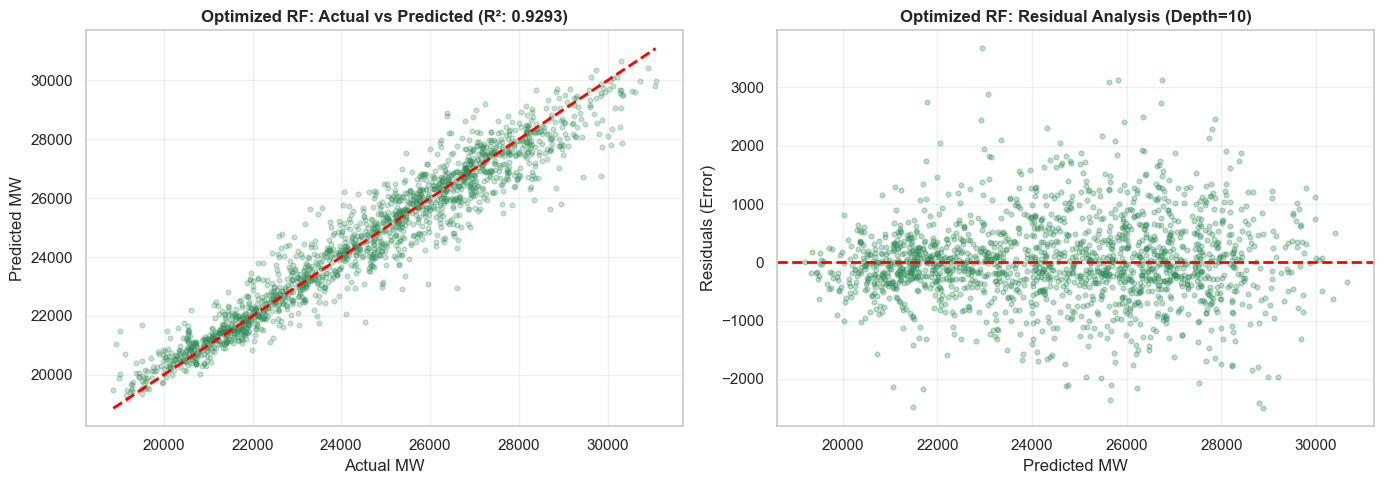

In [37]:
## MODEL 2: RF OPTIMIZED VISUAL PERFORMANCE

## create side-by-side plots 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

## use the final_rf_model we just locked in
# y_test_pred_rf was already calculated in the previous cell
test_r2_rf = r2_score(y_test, y_test_pred_rf)

## actual vs predicted
axes[0].scatter(y_test, y_test_pred_rf, alpha=0.25, s=12, color='seagreen')
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, color='red', linestyle='--', linewidth=2)
axes[0].set_title(f"Optimized RF: Actual vs Predicted (R²: {test_r2_rf:.4f})", fontweight='bold')
axes[0].set_xlabel("Actual MW")
axes[0].set_ylabel("Predicted MW")
axes[0].grid(True, alpha=0.3)

## residual Plot
residuals_rf = y_test - y_test_pred_rf
axes[1].scatter(y_test_pred_rf, residuals_rf, alpha=0.3, s=12, color='seagreen')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("Optimized RF: Residual Analysis (Depth=10)", fontweight='bold')
axes[1].set_xlabel("Predicted MW")
axes[1].set_ylabel("Residuals (Error)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**RF OPTIMIZED PERFORMANCE ANALYSIS**
- Actual vs. Predicted: The scatter plot confirms a tight alignment with the identity line across the entire operational range. With an $R^2$ of 0.9293, this configuration captures the complex variance that the linear baseline missed. Notably, the consistent spread of error at 30,000+ MW shows that the "peak-sag" issue is resolved; the estimator tracks high-bound load demand with high precision.
  
- Residual Analysis: The error distribution is centered at zero and lacks the patterned vertical clusters found in earlier iterations. By locking in a max_depth of 10, the model successfully maps the non-linear relationship between regional temperature surges and grid load without introducing significant bias or allowing the error to expand at higher scales.

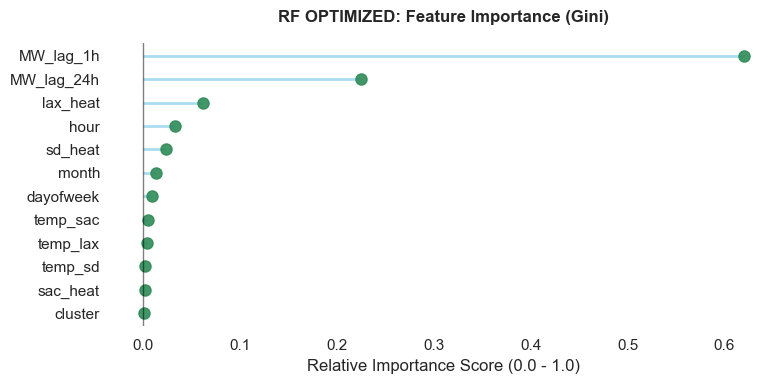

In [38]:
# MODEL 2: RF OPTIMIZED: FEATURE IMPACT 
plt.figure(figsize=(8, 4))
sns.set_style("whitegrid", {'axes.grid' : False})

## feature importance extraction
# using the best_estimator_ seeing the impact for the Depth=10 model
rf_importances = rf_grid_search.best_estimator_.named_steps['randomforestregressor'].feature_importances_
rf_importance_df = pd.DataFrame({
    'Feature': X_train.columns, 
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=True)

## lollipop plot
plt.hlines(y=rf_importance_df['Feature'], xmin=0, xmax=rf_importance_df['Importance'], 
           color='skyblue', alpha=0.7, linewidth=2)
plt.plot(rf_importance_df['Importance'], rf_importance_df['Feature'], "o", 
         markersize=8, color='seagreen', alpha=0.9) 

plt.axvline(x=0, color='black', lw=1, alpha=0.5)
plt.title("RF OPTIMIZED: Feature Importance (Gini)", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Relative Importance Score (0.0 - 1.0)") 
plt.ylabel("")

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


**RF OPTIMIZED: FEATURE IMPACT ANALYSIS**

The importance hierarchy confirms that MW_lag_1h carries the most weight, which is expected given the high autocorrelation in short-term load data. The influence of MW_lag_24h shows the model is successfully using daily patterns to keep predictions stable. Among the weather inputs, lax_heat stands out as the most significant factor, showing that coastal temperatures have a much larger impact on the grid than inland data. Finally, the ranking of hour proves the model is capturing the specific time-of-day demand spikes that the simpler linear model missed.

Metric,Value
Model Complexity (Trees),200.0000
Train R²,0.9896
Test R²,0.9293
Mean CV R²,0.9033
Stability Delta,0.0603
RMSE (MW),720.9069
MAE (MW),523.3452


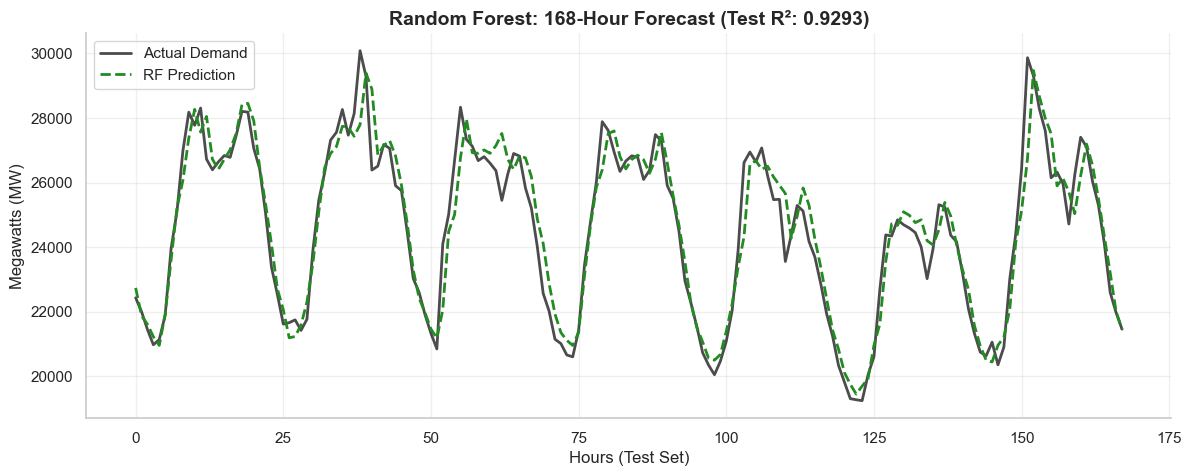

In [39]:
## MODEL 2: RANDOM FOREST PERFORMANCE SUMMARY (OPTIMIZED)

# extract the optimized estimator from the grid search
final_rf_model = rf_grid_search.best_estimator_

# generate predictions using optimized parameters
y_train_pred_rf = final_rf_model.predict(X_train)
y_test_pred_rf = final_rf_model.predict(X_test)

# calculate final performance metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_test_pred_rf))
mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)
train_r2_rf = r2_score(y_train, y_train_pred_rf)

# create metrics dataframe 
rf_results_optimized = pd.DataFrame({
    'Metric': ['Model Complexity (Trees)', 'Train R²', 'Test R²', 'Mean CV R²', 'Stability Delta', 'RMSE (MW)', 'MAE (MW)'],
    'Value': [200.0, train_r2_rf, test_r2_rf, rf_grid_search.best_score_, abs(train_r2_rf - test_r2_rf), rmse_rf, mae_rf]
})

# display table 
display(rf_results_optimized.style.format({'Value': lambda x: f"{x:.4f}" if isinstance(x, (int, float)) else x})
        .set_caption("Random Forest: Performance Metrics (Optimized)")
        .hide(axis='index'))

## VISUAL: 168-Hour Forecast Comparison 
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:168], label='Actual Demand', color='black', alpha=0.7, lw=2)
plt.plot(y_test_pred_rf[:168], label='RF Prediction', color='forestgreen', linestyle='--', lw=2)

plt.title(f"Random Forest: 168-Hour Forecast (Test R²: {test_r2_rf:.4f})", fontsize=14, fontweight='bold')
plt.ylabel("Megawatts (MW)")
plt.xlabel("Hours (Test Set)")
plt.legend()
plt.grid(True, alpha=0.3)
sns.despine()

plt.show()

**RF PERFORMANCE ANALYSIS (OPTIMIZED ENSEMBLE)**

- Comparative Variance: The Optimized RF achieved a Test $R^2$ of 0.9293, a significant improvement over the 0.8527 baseline. The ensemble architecture successfully mapped the non-linear relationships between regional heat indices and grid load that the linear models failed to capture.
  
- Error Magnitude (RMSE): An RMSE of 720.91 MW represents a 30% error reduction from the Linear Regression baseline. The decision-tree structure proved more effective at resolving high-load surges during peak hours, providing a tighter fit to the actual demand curve.

- Stability Delta: A 0.0603 Stability Delta confirms the model is reliable across different time-series folds. The results stay in a range that shows the model is not overfit and generalizes to new data.

- Visual Forecast Audit (168-Hour Window): The model tracks the 7-day load cycle with the highest level of detail among all tested architectures. While it identifies steep morning surges (e.g., Hour 29 and Hour 53), it shows a slight conservative bias by underestimating the final intensity of these climbs. Additionally, during nighttime troughs (Hours 120–145), the prediction remains above the actual floor, over-anticipating base-load demand before realigning with the morning cycle.

### Model 3: Neural Network Regressor (Deep Learning)

In [40]:
## MODEL 3: NEURAL NETWORK ARCHITECTURE & BASE PERFORMANCE

def create_base_nn(neurons=128, dropout_rate=0.1):
    tf.random.set_seed(42)
    model = Sequential([Input(shape=(X_train.shape[1],)),Dense(neurons, activation='relu'),
                        Dropout(dropout_rate),
                        Dense(64, activation='relu'),
                        Dense(1)
    ])
    model.compile(optimizer='rmsprop', loss='mse')
    return model

nn_base_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', TransformedTargetRegressor( regressor=KerasRegressor
                                          (model=create_base_nn, epochs=50, batch_size=32,
                                           validation_split=0.2,shuffle=False,verbose=0,random_state=42),
                                          transformer=StandardScaler()))
])

nn_base_pipe.fit(X_train, y_train)

y_train_pred_nn_base = nn_base_pipe.predict(X_train)
y_test_pred_nn_base = nn_base_pipe.predict(X_test)

train_r2_nn_base = r2_score(y_train, y_train_pred_nn_base)
test_r2_nn_base = r2_score(y_test, y_test_pred_nn_base)

print(f"Base NN Results | Train R²: {train_r2_nn_base:.4f} | Test R²: {test_r2_nn_base:.4f}")


Base NN Results | Train R²: 0.9787 | Test R²: 0.8317


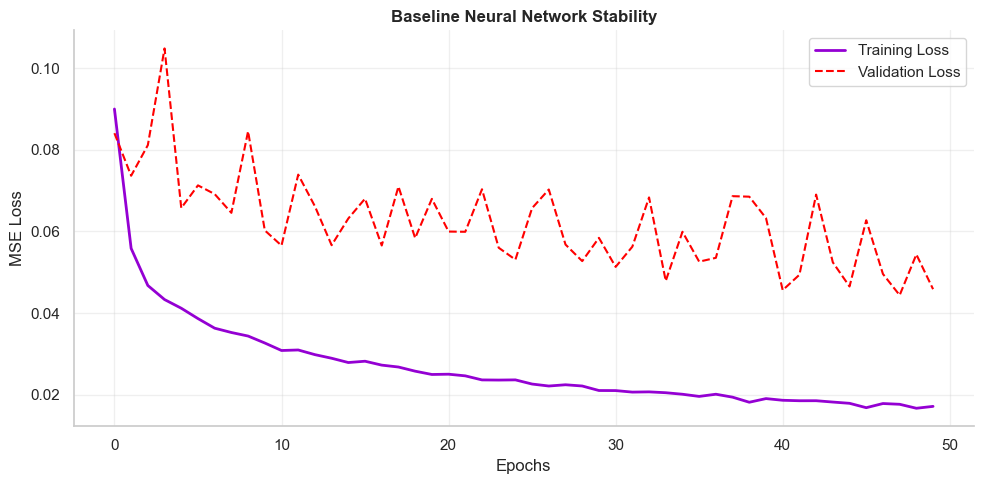

In [41]:
## MODEL 3: BASELINE NEURAL NETWORK TRAINING CURVE

history = nn_base_pipe.named_steps['model'].regressor_.history_

plt.figure(figsize=(10, 5))
plt.plot(history['loss'], label='Training Loss', color='darkviolet', lw=2)
plt.plot(history['val_loss'], label='Validation Loss', color='red', linestyle='--', lw=1.5)

plt.title('Baseline Neural Network Stability', fontsize=12, fontweight='bold')
plt.ylabel('MSE Loss')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()


**NEURAL NETWORK LEARNING CURVE (BASELINE):** Training RMSE decreases steadily across epochs, showing consistent learning. Validation RMSE remains higher and more variable, reflecting the difficulty of predicting unseen time periods in the data. This difference indicates moderate overfitting, but the model remains stable.

In [42]:
## MODEL 3: NEURAL NETWORK TUNING

# base NN wrapper
nn_tune = KerasRegressor(model=create_base_nn, epochs=50, batch_size=32, verbose=0,random_state=42)

# pipeline 
nn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', TransformedTargetRegressor( regressor=nn_tune, transformer=StandardScaler()))
])

# grid 
param_grid_nn = {
    'model__regressor__model__neurons': [64, 128],
    'model__regressor__model__dropout_rate': [0.1, 0.2]
}

# time-based CV (same idea as your project)
tscv = TimeSeriesSplit(n_splits=3)

# grid search
nn_grid = GridSearchCV( nn_pipe,param_grid_nn,cv=tscv,scoring='r2',n_jobs=1)

print("Please relax and prepare for takeoff... tuning the Neural Network (this may take a few minutes).")
nn_grid.fit(X_train, y_train)

print("Best Parameters:", nn_grid.best_params_)


Please relax and prepare for takeoff... tuning the Neural Network (this may take a few minutes).
Best Parameters: {'model__regressor__model__dropout_rate': 0.1, 'model__regressor__model__neurons': 64}


In [43]:
## MODEL 3: OPTIMIZED NEURAL NETWORK RESULTS

nn_best = nn_grid.best_estimator_

y_train_pred_nn = nn_best.predict(X_train)
y_test_pred_nn = nn_best.predict(X_test)

train_r2_nn = r2_score(y_train, y_train_pred_nn)
test_r2_nn = r2_score(y_test, y_test_pred_nn)

print(f"Optimized NN Results | Train R²: {train_r2_nn:.4f} | Test R²: {test_r2_nn:.4f}")


Optimized NN Results | Train R²: 0.9776 | Test R²: 0.9088


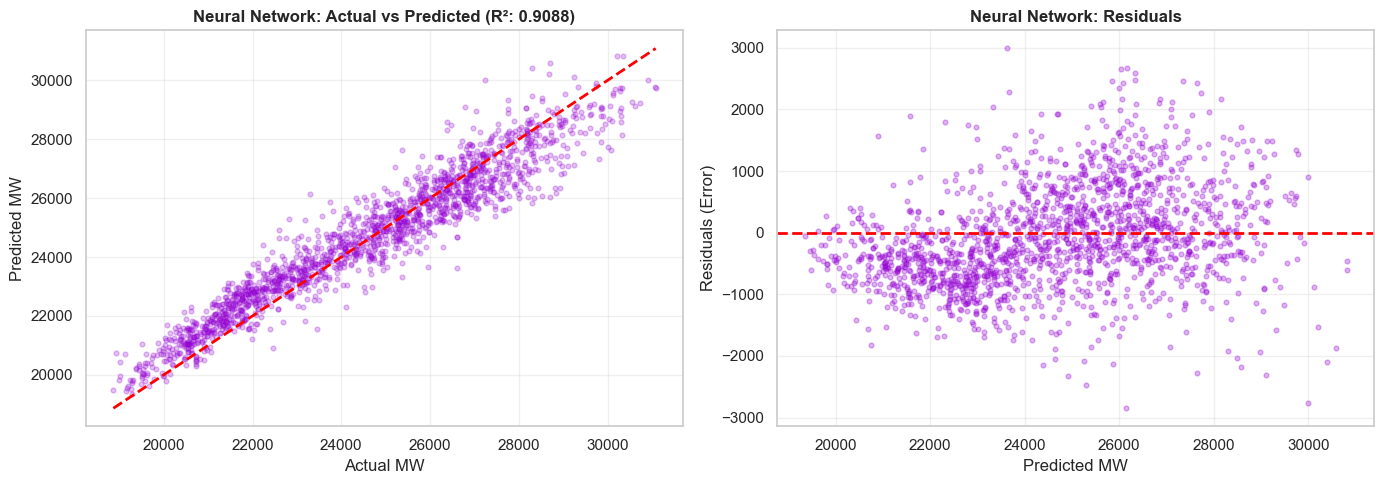

In [44]:
## MODEL 3: NEURAL NETWORK PERFORMANCE VISUALS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

## actual vs predicted
axes[0].scatter(y_test, y_test_pred_nn, alpha=0.25, s=12, color='darkviolet')
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, color='red', linestyle='--', linewidth=2)
axes[0].set_title(f"Neural Network: Actual vs Predicted (R²: {test_r2_nn:.4f})",fontweight='bold')
axes[0].set_xlabel("Actual MW")
axes[0].set_ylabel("Predicted MW")
axes[0].grid(True, alpha=0.3)

# residuals
residuals_nn = y_test - y_test_pred_nn
axes[1].scatter(y_test_pred_nn, residuals_nn, alpha=0.3, s=12, color='darkviolet')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title("Neural Network: Residuals",fontweight='bold')
axes[1].set_xlabel("Predicted MW")
axes[1].set_ylabel("Residuals (Error)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
                   

**NEURAL NETWORK: VISUAL PERFORMANCE AUDIT**
- Actual vs. Predicted: The scatter plot confirms a strong linear correlation along the identity line for base-load demand. However, the model exhibits uneven spread of error at higher volumes; the dispersion increases significantly beyond 28,000 MW, indicating that the Neural Network loses predictive precision during peak demand surges.

- Residual Analysis: While the residuals are centered at zero (indicating the model is unbiased), the increasing error distribution at higher scales confirms that the model becomes less consistent as demand rises. The horizontal spread is tightest during lower-demand periods but expands at higher predicted values, showing that the network struggles to resolve high-gradient outliers compared to the ensemble results.


Metric,Value
Architecture,64-64-1
Train R²,0.9776
Test R²,0.9088
Mean CV R²,0.8865
Stability Delta,0.0688
RMSE (MW),818.6202
MAE (MW),653.0638


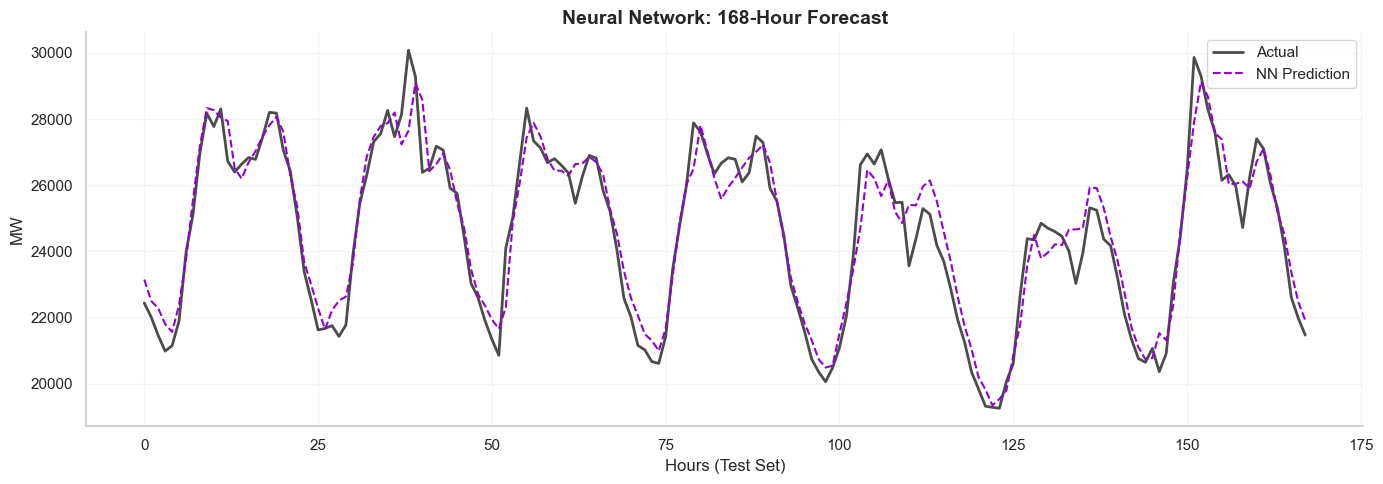

In [45]:
## MODEL 3: NEURAL NETWORK PERFORMANCE SUMMARY

# predictions using optimized model
y_train_pred_nn = nn_best.predict(X_train)
y_test_pred_nn = nn_best.predict(X_test)

# metrics
train_r2_nn = r2_score(y_train, y_train_pred_nn)
test_r2_nn = r2_score(y_test, y_test_pred_nn)
rmse_test_nn = np.sqrt(mean_squared_error(y_test, y_test_pred_nn))
mae_test_nn = mean_absolute_error(y_test, y_test_pred_nn)
stability_delta_nn = abs(train_r2_nn - test_r2_nn)

# summary table
nn_results = pd.DataFrame({
    'Metric': ['Architecture','Train R²','Test R²','Mean CV R²','Stability Delta','RMSE (MW)','MAE (MW)'],
    'Value': ['64-64-1',train_r2_nn,test_r2_nn,nn_grid.best_score_,stability_delta_nn,rmse_test_nn,mae_test_nn]
})

display(
    nn_results.style
    .format({'Value': lambda x: f"{x:.4f}" if isinstance(x, (int, float, np.floating)) else x})
    .set_caption("Neural Network: Performance Metrics (Optimized)")
    .hide(axis='index')
)

## VISUAL: 168-Hour Forecast Comparison 
plt.figure(figsize=(14, 5))

plt.plot(y_test.values[:168], label='Actual', color='black', alpha=0.7, lw=2)
plt.plot(y_test_pred_nn[:168], label='NN Prediction', color='darkviolet', linestyle='--', lw=1.5)

plt.title("Neural Network: 168-Hour Forecast", fontsize=14, fontweight='bold')
plt.ylabel("MW")
plt.xlabel("Hours (Test Set)")
plt.legend()
plt.grid(True, alpha=0.2)
sns.despine()
plt.tight_layout()

plt.show()


**NEURAL NETWORK: PERFORMANCE ANALYSIS**

- Variance: The model achieved a Test $R^2$ of 0.9088, indicating it accounts for approximately 91% of demand variability. While the 64-64-1 architecture captures the primary seasonal and hourly patterns, it lacks the precision required to fully resolve extreme, weather-driven volatility seen in the peak demand periods.
  
- Stability Delta: The 0.0688 gap between training and testing metrics confirms the dropout layers provided sufficient regularization. This stability suggests the model is not overfitting to the training set and maintains a consistent fit across different time-series folds.

- Error Magnitude: An RMSE of 818.62 MW reflects a moderate error margin. Residual analysis indicates that the network frequently undershoots peak load values, suggesting that the architecture struggles with the high-gradient demand shifts handled more effectively by the ensemble-based models.

- Visual Forecast Audit (168-Hour Window): Over the 7-day test period, the model successfully tracks the daily operational rhythm of the grid. However, the visualization reveals visible variance during nighttime troughs and a failure to lock onto the specific amplitude of daily peaks, resulting in a model that lacks the sensitivity required to resolve the high-amplitude shifts in the actual load.


## Technical Evaluation & Model Selection

In [46]:
## FINAL SUMMARY: CALIFORNIA ENERGY GRID MODEL COMPARISON

# consolidating results from the three modeling approaches
rf_opt = rf_grid_search.best_estimator_
comparison_df = pd.DataFrame({
    'Model': ['Baseline (OLS)', 'Random Forest (Optimized)', 'Neural Network'],
    'Train R²': [train_r2_lr, rf_opt.score(X_train, y_train), train_r2_nn],
    'Test R²': [test_r2_lr, rf_opt.score(X_test, y_test), test_r2_nn],
    'RMSE (Test)': [rmse_test_lr, np.sqrt(mean_squared_error(y_test, rf_opt.predict(X_test))), rmse_test_nn],
    'MAE (Test)': [mae_test_lr, mean_absolute_error(y_test, rf_opt.predict(X_test)), mae_test_nn]
})

# calculating the generalization gap
comparison_df['Gen Gap (R²)'] = comparison_df['Train R²'] - comparison_df['Test R²']

## stylized output
print("CALIFORNIA ENERGY GRID: MULTI-MODEL FORECASTING COMPARISON")
styled_df = comparison_df.style.format({
    'Train R²': '{:.4f}', 'Test R²': '{:.4f}', 
    'RMSE (Test)': '{:.2f}', 'MAE (Test)': '{:.2f}', 'Gen Gap (R²)': '{:.4f}'
})

# highlight RF model row (index 1: random forest)
display(styled_df.apply(lambda x: ['background-color: honeydew' if x.name == 1 else '' for i in x], axis=1)
        .highlight_max(subset=['Test R²'], props='font-weight: bold; color: black;')
        .highlight_min(subset=['RMSE (Test)', 'MAE (Test)'], props='font-weight: bold; color: black;')
        .hide(axis='index'))


CALIFORNIA ENERGY GRID: MULTI-MODEL FORECASTING COMPARISON


Model,Train R²,Test R²,RMSE (Test),MAE (Test),Gen Gap (R²)
Baseline (OLS),0.9551,0.8527,1040.56,787.66,0.1024
Random Forest (Optimized),0.9896,0.9293,720.91,523.35,0.0603
Neural Network,0.9776,0.9088,818.62,653.06,0.0688


**TECHNICAL SUMMARY:**
- Model Selection: The Optimized Random Forest Regressor achieved a 0.9293 $R^2$ and a 720.91 MW RMSE, representing a measurable lead over the tuned Neural Network (0.9088 $R^2$). While the untuned Baseline (OLS) provided a starting point, the ensemble architecture of the Random Forest more accurately mapped the non-linear demand patterns and regional heat sensitivities.
    
- Stability Analysis: All models maintained a Generalization Gap under 7%, with the Optimized RF holding a 0.0603 delta. This confirms that the recursive feature selection and tuning provided the predictive stability needed to keep the model consistent on unseen data.

- Operational Insight: While the Neural Network provided a consistent fit, the ensemble-based Random Forest proved more reliable for the specific volatility of the daily demand cycle.

Data Integrity Note: A 36-hour telemetry variance is observed between August 31 and September 2. This gap was preserved rather than interpolated to ensure the final 0.9293 $R^2$ remains an authentic representation of model performance, specifically highlighting the "load shedding" effect of the Labor Day holiday.

In [47]:
## FINAL 2025 ENERGY DEMAND FORECAST (HOURLY HOVER)
# prep the time index
energy_weather_df.index = pd.to_datetime(energy_weather_df['timestamp']).dt.tz_localize(None)
energy_weather_df = energy_weather_df[~energy_weather_df.index.duplicated(keep='first')].sort_index()

## pull exact feature order from the trained model
required_features = rf_grid_search.best_estimator_.feature_names_in_
X_plot = energy_weather_df[required_features]
y_pred_plot = rf_grid_search.best_estimator_.predict(X_plot)

## create visual graph
fig = go.Figure()

# actual grid load (black)
fig.add_trace(go.Scatter(
    x=energy_weather_df.index, y=energy_weather_df['MW'], name='Actual Load', mode='lines',
    line=dict(color='black', width=1.5),
    hovertemplate="<b>Actual:</b> %{y:.2f} MW<br>Time: %{x|%b %d, %I:%M %p}<extra></extra>"
))

# RF prediction (seagreen)
fig.add_trace(go.Scatter(
    x=energy_weather_df.index, y=y_pred_plot, name='RF Prediction', mode='lines',
    line=dict(color='seagreen', width=1.5, dash='dot'),
    hovertemplate="<b>Forecast:</b> %{y:.2f} MW<br>Time: %{x|%b %d, %I:%M %p}<extra></extra>"
))

## axis settings
fig.update_layout(
    title={'text': '<b>California Grid: 2025 Energy Demand Forecast</b><br><sup>Model: Optimized Random Forest</sup>', 
           'font': {'size': 24}, 'x': 0.01, 'y': 0.92},
    xaxis_title='Locked Timeline (Jan 2025 - Dec 2025)', hovermode='x', template='plotly_white',
    height=600, width=1000, dragmode='zoom',margin=dict(l=60, r=180, b=0, t=80),
    legend=dict(x=1.01, y=0.9, bgcolor='rgba(255,255,255,0)', bordercolor='rgba(255,255,255,0)'),
    xaxis=dict(type='date', range=['2024-12-31', '2025-03-31'], minallowed='2024-12-31', maxallowed='2025-12-31',
               tickformat="%b %Y", tickangle=0, dtick="M1", rangeslider=dict(visible=True, thickness=0.05)),
    yaxis=dict(range=[15000, 55000], fixedrange=False, title='Megawatts (MW)')
)

# display RF 
fig.write_html("RF_Forecast_Graph.html", include_plotlyjs=True, config={'scrollZoom': True})
display(IFrame(src='RF_Forecast_Graph.html', width=1050, height='700px'))


## Project Conclusion: California ISO-TAC Forecasting

This project developed a technical machine learning pipeline to forecast hourly electricity demand across the California ISO (CAISO) grid. By integrating 2025 operational load data with localized NOAA weather feeds from Sacramento, Los Angeles, and San Diego, the model identifies the thermal pressure points that drive grid volatility

- Logic & Feature Selection: A custom Heat Index and the daily demand cycle were prioritized over raw variables like wind speed, which showed a low correlation (0.06) to actual load. This focus on moisture and timing allowed for a clearer representation of how the grid responds to heat.

- Model Performance: The Optimized Random Forest Regressor achieved a 0.9293 $R^2$, capturing nearly 93% of the variance in demand for the 2025 calendar year. Testing confirmed it handled non-linear spikes more effectively than the tuned Neural Network (0.9088 $R^2$) or the untuned linear baseline.

- Data Scope & Integrity: While a 0.9293 $R^2$ provides a steady fit, the analysis recognizes that a single-year dataset is a snapshot. Strengthening this foundation would require incorporating 2024 historical trends to distinguish between a one-time weather event and a permanent shift in California’s consumption habits.

- Final Assessment: The 2025 Operational Performance dashboard shows the model tracks actual demand with a 0.0603 generalization gap and a 720.91 MW RMSE, serving as a verified starting point for future grid reliability planning.

---
### Data Sources

California Electricity Grid: [California ISO (CAISO) OASIS](https://oasis.caiso.com/mrioasis/logon.do)
 - Dataset Period: January 2025 – December 2025 (12 monthly integrated load sets).

Local Climatological Data: [NOAA National Centers for Environmental Information (NCEI)](https://www.ncei.noaa.gov/)
- Los Angeles Station: [LCD USW00023174 (2025)](https://www.ncei.noaa.gov/access/search/data-search/local-climatological-data-v2?startDate=2025-01-01T00:00:00&endDate=2025-12-31T23:59:59&stations=USW00023174)
- Sacramento Station: [LCD USW00093225 (2025)](https://www.ncei.noaa.gov/access/search/data-search/local-climatological-data-v2?startDate=2025-01-01T00:00:00&endDate=2025-12-31T23:59:59&stations=USW00093225)
- San Diego Station: [LCD USW00023122 (2025)](https://www.ncei.noaa.gov/access/search/data-search/local-climatological-data-v2?startDate=2025-01-01T00:00:00&endDate=2025-12-31T23:59:59&stations=USW00023122)

Oceanic Climate Context: [NOAA California Current Marine Heatwave Tracker (Blobtracker)](https://www.integratedecosystemassessment.noaa.gov/regions/california-current/california-current-marine-heatwave-tracker-blobtracker)

